>
> # Scenario analysis
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [20]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
from scenarios_2D import *
from plot_func import *
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Enter variable and data type
variable_1 = {"name": "nP", "sym": "$K$", "int": True}
variable_2 = {"name": "nV", "sym": "$N$", "int": True}
variables = [variable_1, variable_2]

In [3]:
# Which scenarios we want to investigate
cond_fact = 75000/2500 #val 1 bigger than val 2
cond_val_1 = [0,999999] # min, max
cond_val_2 = [0,999999] # min, max
conds = [cond_fact, cond_val_1, cond_val_2]

In [4]:
# # Establish which scenarios we have
# dir_name = os.path.join(os.getcwd(),'input',variable_1["name"]+'-'+variable_2["name"])
# extension = ".zip"
# slct_scns = []
# pos = [2,4]
# for item in os.listdir(dir_name): # loop through items in dir
#     if item.endswith(extension): # check for ".zip" extension
#         zip_file_name = os.path.join(dir_name,item) # get full path of files
        
#         strval_1 = re.split('_|-', item)[pos[0]]
#         strval_2 = re.split('_|-', item)[pos[1]]
#         val_1 = int(strval_1) if variable_1["int"] else float(strval_1)
#         val_2 = int(strval_2) if variable_2["int"] else float(strval_2)
        
#         if (val_1 / val_2 == cond_fact) and (cond_val_1[0] <= val_1 <= cond_val_1[1]) and (cond_val_2[0] <= val_2 <= cond_val_2[1]):
#             if strval_1 + '_' + strval_2 not in slct_scns:
#                 slct_scns.append(strval_1+ '_' + strval_2)
# slct_scns

In [5]:
pos = [2,4]
dir_name = os.path.join(os.getcwd(),'input',variable_1["name"]+'-'+variable_2["name"])
res, micro, params, drivers, requests, var_val = load_results_2d_edit(dir_name, pos, variables, conds)

# Find variable values that have been tested
vals, scn = find_vals_2d(var_val, variable_1, variable_2)

# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res)

In [6]:
vals_1 = set([i.split('_', 1)[0] for i in vals])
vals_2 = set([i.split('_', 1)[1] for i in vals])

abc_1 = set(map(int, [i.split('_', 1)[0] for i in vals]))
abc_2 = set(map(int, [i.split('_', 1)[1] for i in vals]))

In [7]:
for i in range(len(res.sup)):
    if 'rejected_reg' not in res.sup[i].columns:
        res.sup[i]['rejected_reg'] = np.zeros(len(res.sup[i].index))
        res.sup[i]['reject_particip'] = np.zeros(len(res.sup[i].index))

In [8]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl['scn'] = var_val
conv_repl.head(50)
# conv_repl[conv_repl.scn == '60000_250']

,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged,scn


In [9]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 5/4 for scenario 15000_500
Sufficient number of replications: 5/1 for scenario 30000_1000
Sufficient number of replications: 35/11 for scenario 3750_125
Sufficient number of replications: 5/1 for scenario 45000_1500
Sufficient number of replications: 5/1 for scenario 60000_2000
Sufficient number of replications: 5/1 for scenario 75000_2500
Sufficient number of replications: 20/19 for scenario 7500_250


In [10]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [12]:
eql_scn.sup

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,...,driver_surplus,mean_rev,mean_op_costs,ivt_costs,dh_costs,mean_dh_dist,mean_dh_time,drive_time,not_idle_time,share_idle_time
scenario,,,,,,,,,,,,,,,,,,,,,
15000_500,500.0,28.680000,0.0,13.880000,0.0,66.291138,66.620772,67.081467,61.691249,0.498743,...,-321.519977,87.865946,26.174697,16.381054,9.793643,39.174572,3917.457176,6552.421633,10469.878808,0.636463
30000_1000,1000.0,60.720000,0.0,37.040000,0.0,73.544354,74.513045,74.071604,72.685222,0.551105,...,-245.714228,99.252448,26.567226,18.560051,8.007175,32.028701,3202.870066,7424.020451,10626.890517,0.631011
3750_125,125.0,3.045714,0.0,0.062857,0.0,31.792885,35.314551,32.152828,33.462979,0.237385,...,-60.323715,58.000369,24.537390,10.613971,13.923419,55.693675,5569.367500,4245.588333,9814.955833,0.659203
45000_1500,1500.0,103.360000,0.0,64.840000,0.0,75.279190,76.297308,75.195434,73.835387,0.569310,...,-246.803106,98.375629,24.540242,18.422321,6.117922,24.471687,2447.168669,7368.928306,9816.096975,0.659163
60000_2000,2000.0,136.480000,0.0,88.080000,0.0,77.241606,78.414578,77.120110,78.374296,0.580997,...,14.278199,103.345312,24.971016,19.381558,5.589458,22.357831,2235.783106,7752.623341,9988.406446,0.653180
75000_2500,2500.0,182.240000,0.0,118.680000,0.0,76.588005,77.727358,76.920121,76.994954,0.577458,...,-233.802018,100.698958,23.704004,18.895458,4.808546,19.234183,1923.418275,7558.183305,9481.601581,0.670778
7500_250,250.0,8.850000,0.0,2.570000,0.0,55.926127,55.287732,54.434442,58.893763,0.421146,...,-132.812511,96.058037,37.164275,17.803944,19.360331,77.441324,7744.132400,7121.577410,14865.709810,0.483830


In [13]:
eql_scn.plf.head(5)

,plat_profit
15000_500,401.897925
30000_1000,1221.582180
3750_125,17.949465
45000_1500,2117.924055
60000_2000,3027.151830


In [14]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['plat_profit']

In [15]:
# Add scenario values as columns to df
eql_scn.sup = add_scn_vals(eql_scn.sup, variable_1, variable_2)
eql_scn.dem = add_scn_vals(eql_scn.dem, variable_1, variable_2)
eql_scn.plf = add_scn_vals(eql_scn.plf, variable_1, variable_2)

# eql_scn.plf[variable_1["name"]] = eql_scn.plf.index.str.split('_').str.get(0).astype(int)
# eql_scn.plf[variable_2["name"]] = eql_scn.plf.index.str.split('_').str.get(1).astype(int)
# eql_scn.index.name = 'scenario'

# # Add missing scenarios to df as nan's
# scn_names = []
# for val_1 in vals_1:
#     for val_2 in vals_2:
#         scn_name = str(val_1)+'_'+str(val_2)
#         scn_names.append(scn_name)
#         if scn_name not in eql_scn.plf.index:
#             eql_scn.plf = eql_scn.plf.append(pd.Series(data={'profit': np.nan,'nP': int(val_1), 'nV': int(val_2)}, name = scn_name), ignore_index=False)

# eql_scn.plf = eql_scn.plf.sort_values(["nP", "nV"])
# eql_scn.plf = eql_scn.plf.set_index(['nP','nV'])
# eql_scn.plf = eql_scn.plf.unstack(level=-1)
# eql_scn.plf.style.background_gradient(axis=None)

In [16]:
# # eql_scn.plf = eql_scn.plf.pivot(index='nP', columns='nV', values='profit')
# # sns.heatmap(data)
# sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values='profit'))
# plt.show()

In [17]:
# Find societal value
eql_scn.soc = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
eql_scn.soc = pd.DataFrame(eql_scn.soc.values, index = vals, columns = ['soc_value'])
eql_scn.soc = add_scn_vals(eql_scn.soc, variable_1, variable_2)

C:\Users\arjanderuijter\Anaconda3\envs\MS_venv\lib\site-packages\seaborn\matrix.py:204: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\arjanderuijter\Anaconda3\envs\MS_venv\lib\site-packages\seaborn\matrix.py:209: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


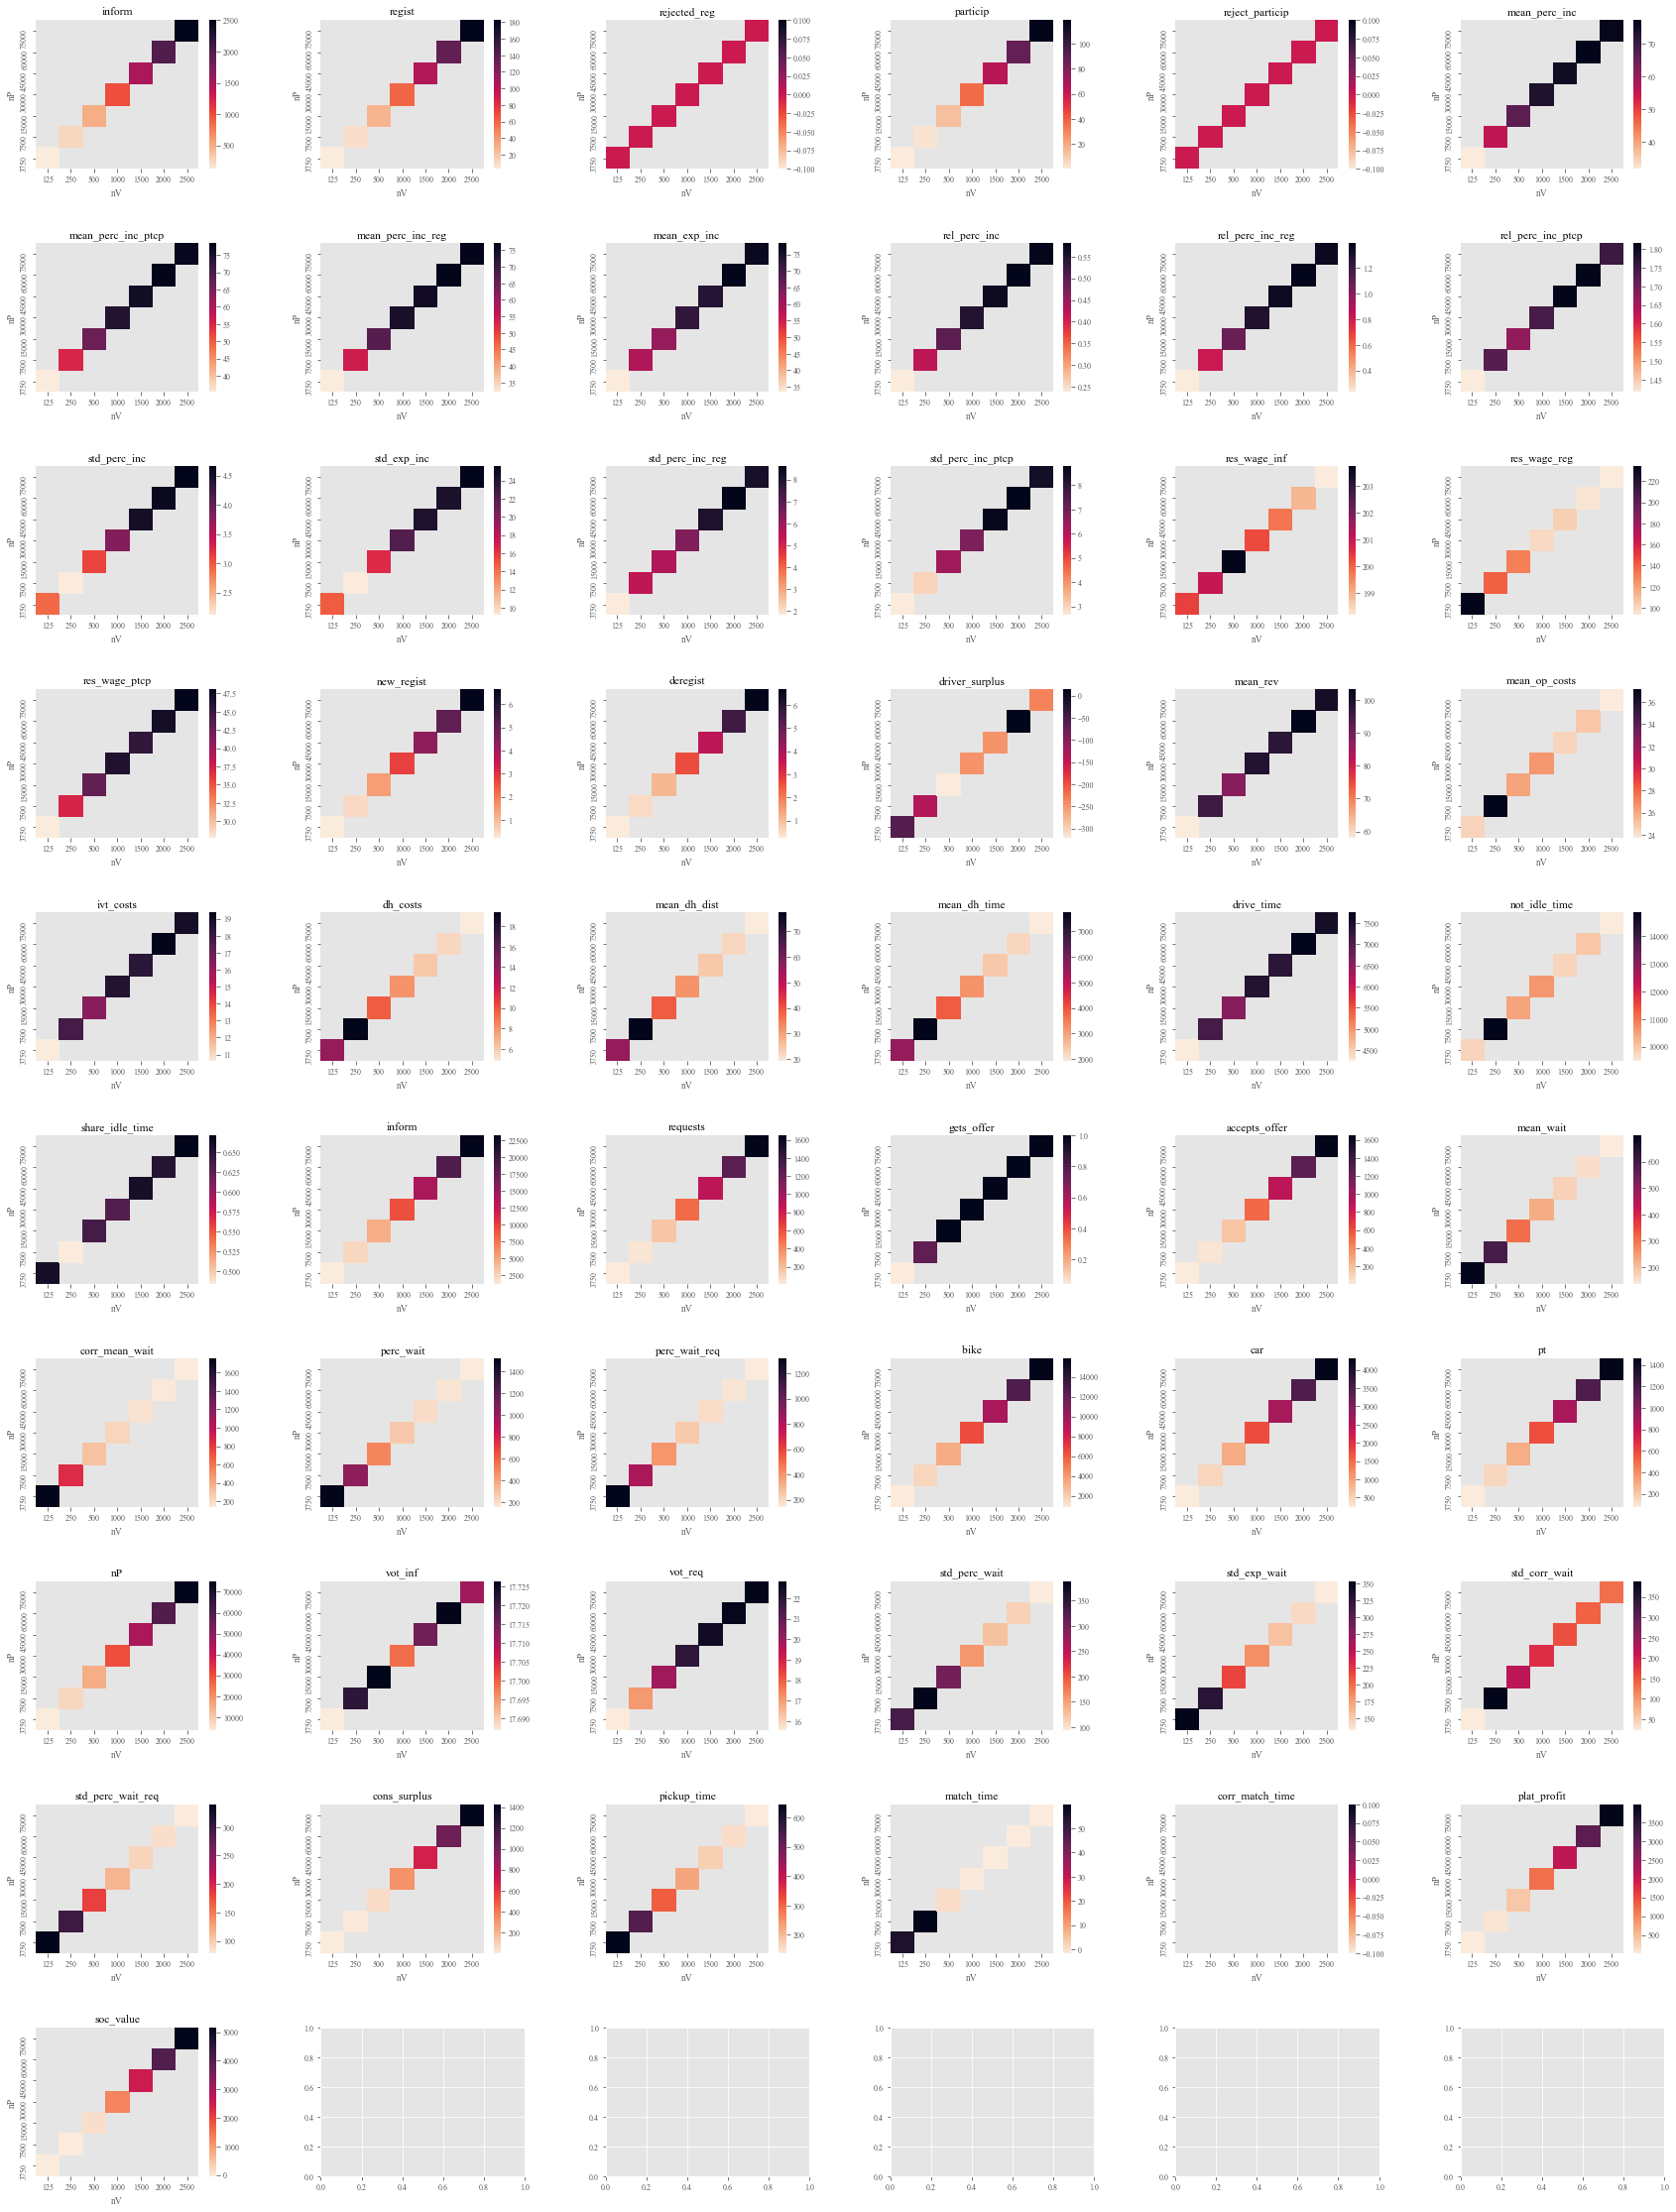

In [21]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(10, 6, figsize = [30,40])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

i = 0
j = 0
for kpi in kpis_sup:
    axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_dem:
    axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_plf:
    axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1
        
axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i], cmap=cmap)
axes[j, i].set_title('soc_value')
axes[j, i].invert_yaxis()
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'heat_maps.jpg'),dpi=300,bbox_inches='tight')

In [22]:
res.sup[0]

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,...,driver_surplus,mean_rev,mean_op_costs,ivt_costs,dh_costs,mean_dh_dist,mean_dh_time,drive_time,not_idle_time,share_idle_time
day,,,,,,,,,,,,,,,,,,,,,
0,50,8,0,2,0,216.100831,278.301620,274.070291,75.510625,1.000000,...,-565.581991,127.483313,51.972688,24.329625,27.643063,110.572250,11057.225000,9731.850000,20789.075000,0.278157
1,53,8,0,4,0,186.280954,264.958096,263.930741,38.932187,0.881635,...,-1079.489226,63.120375,24.188187,11.776750,12.411437,49.645750,4964.575000,4710.700000,9675.275000,0.664053
2,58,8,0,2,0,150.017912,302.054200,241.328151,77.422500,0.723417,...,-609.263401,120.843563,43.421063,22.479125,20.941938,83.767750,8376.775000,8991.650000,17368.425000,0.396930
3,64,8,0,0,0,132.700964,NaN,230.096566,NaN,0.672369,...,-160.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,72,8,0,1,0,132.700964,113.100668,230.096566,96.518750,0.670245,...,-176.581918,151.719750,55.201000,29.215500,25.985500,103.942000,10394.200000,11686.200000,22080.400000,0.233319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,500,27,0,11,0,64.704505,65.595917,64.512327,58.145000,0.484126,...,-311.260935,83.075523,24.930523,15.393045,9.537477,38.149909,3814.990909,6157.218182,9972.209091,0.653743
196,500,29,0,15,0,63.373287,64.489909,63.780824,55.282917,0.474288,...,-380.368588,76.958850,21.675933,14.385300,7.290633,29.162533,2916.253333,5754.120000,8670.373333,0.698945
197,500,28,0,13,0,62.019107,62.780887,63.173311,59.653942,0.463344,...,-272.754655,84.283096,24.629154,15.691115,8.938038,35.752154,3575.215385,6276.446154,9851.661538,0.657928


In [23]:
micro.dem.corr_wait_time[0]
micro.sup.keys()

odict_keys(['inform', 'regist', 'ptcp', 'perc_inc', 'exp_inc'])

In [24]:
# requests[0]
# res.sup[0]
# res.dem[0]
params[0]
# res.sup[3]
# res.dem[3]

{'NAME': 'default',
 'city': 'Amsterdam, Netherlands',
 'nP': 15000,
 'nV': 500,
 'times': {'request': 15,
  'transaction': 20,
  'pickup': 30,
  'dropoff': 10,
  'patience': 600,
  'pickup_patience': 90},
 'speeds': {'walk': 1.2, 'ride': 10, 'bike': 4.0, 'pt': 5.0},
 't0': '2022-02-17 13:58:34',
 'paths': {'main': '/Users/rkucharski/Documents/GitHub/MaaSSim',
  'data': '/Users/rkucharski/Documents/GitHub/MaaSSim/data',
  'params': '/Users/rkucharski/Documents/GitHub/MaaSSim/data/configs',
  'G': 'data/graphs/Amsterdam.graphml',
  'skim': 'data/graphs/Amsterdam.csv',
  '_ipython_display_': {},
  '_repr_mimebundle_': {},
  '_repr_html_': {},
  '_repr_markdown_': {},
  '_repr_svg_': {},
  '_repr_png_': {},
  '_repr_pdf_': {},
  '_repr_jpeg_': {},
  '_repr_latex_': {},
  '_repr_json_': {},
  '_repr_javascript_': {},
  'albatross': 'data/albatross'},
 'dist_threshold': 100000,
 'big_time': 10,
 'sleep': False,
 'simTime': 8,
 'demand_structure': {'origins_dispertion': -0.0003,
  'destinati

In [25]:
# abc = micro.dem.corr_wait_time[3]
# abc = abc.replace(params[3]['evol']['travellers']['reject_penalty'], np.nan)
# # abc.max()[0] == params[3]['evol']['travellers']['reject_penalty']
# abc = ~abc.isna()
# rs_fare = params[3]['platforms']['base_fare'] + params[3]['platforms']['fare'] * requests[3].dist / 1000
# # rs_fare
# # abc= abc.mul(rs_fare, axis=0)
# # abc = abc.sum(axis=0)
# # abc = abc.div(res.sup[3].particip, axis=0)
# # abc = abc / res.sup[3].particip.to_numpy()
# # abc
# pax_dist = abc.mul(requests[3].dist,axis=0)
# # .sum(axis=0) / 1000
# # pax_dist.sum()
# fare_acc_req = abc.mul(rs_fare, axis=0)
# total_fares = fare_acc_req.sum(axis=0)
# hup = total_fares / res.sup[3].particip.to_numpy()
# res.sup[3]['hup'] = hup.to_numpy()
# res.sup[3]
# # pax_dist = (abc.mul(requests[3].dist,axis=0)).sum(axis=0) / 1000
# # pax_dist
# abc.sum()
# pax_dist.sum() / 1000

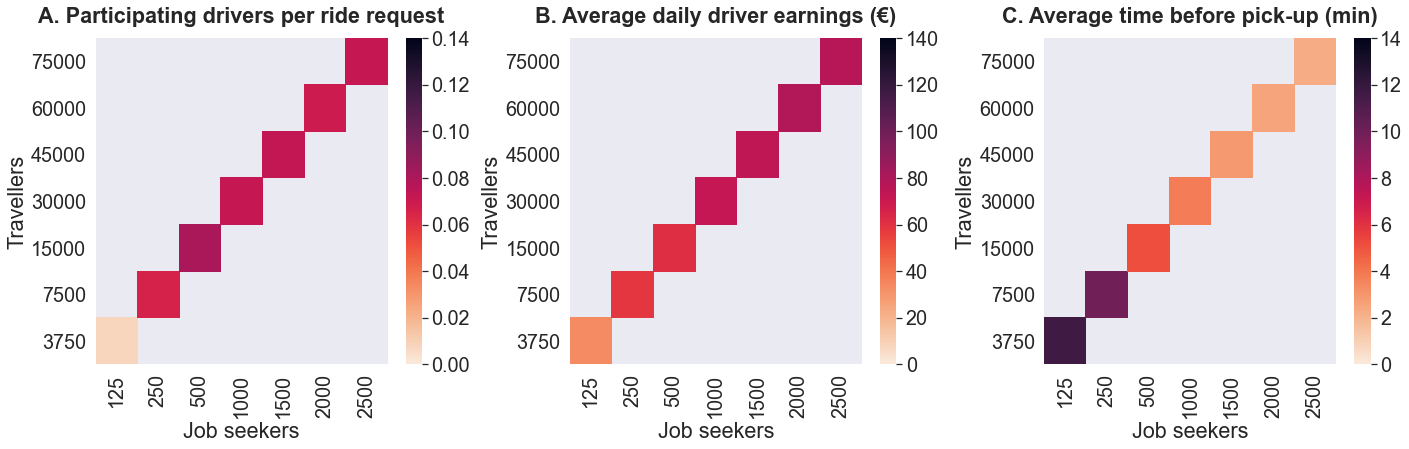

In [26]:
cmap = sns.cm.rocket_r
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 3, figsize = [24,6])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.4, wspace=0.3, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[2,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,3], cmap=cmap)
# axes[2,3].set_title('Participation rel. to job seekers')
# axes[2,3].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.sup.particip / res_proc.nP
# axes[2,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,2], cmap=cmap)
# axes[2,2].set_title('Participation rel. to travellers')
# axes[2,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
# axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
# axes[1,2].set_title('Mode share of ridesourcing')
# axes[1,2].invert_yaxis()
# # axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
axes[1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='exp_inc'), ax = axes[1], cmap=cmap, vmin=0, vmax=140)
axes[1].set_title('B. Average daily driver earnings (\u20ac)', fontweight="bold", pad=15)
axes[1].invert_yaxis()
axes[1].set_xlabel('Job seekers')
axes[1].set_ylabel('Travellers')

# res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
# axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[0,3], cmap=cmap)
# axes[0,3].set_title('Average driver earnings per satisfied request')
# axes[0,3].invert_yaxis()


# res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
# axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[1,0], cmap=cmap)
# axes[1,0].set_title('Satisfied requests per participating driver')
# axes[1,0].invert_yaxis()

res_proc['wait_time'] = eql_scn.dem.mean_wait / 60
axes[2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[2], cmap=cmap, vmin=0, vmax=14)
axes[2].set_title('C. Average time before pick-up (min)', fontweight="bold", pad=15)
axes[2].invert_yaxis()
axes[2].set_xlabel('Job seekers')
axes[2].set_ylabel('Travellers')

# res_proc['regist'] = eql_scn.sup.regist / eql_scn.sup.inform
# axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='regist'), ax = axes[0,0], cmap=cmap)
# axes[0,0].set_title('Share of job seekers with registration')
# axes[0,0].invert_yaxis()

# res_proc['ptcp_prob'] = eql_scn.sup.particip / eql_scn.sup.regist
# axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='ptcp_prob'), ax = axes[0,1], cmap=cmap)
# axes[0,1].set_title('Average participation frequency')
# axes[0,1].invert_yaxis()

# res_proc['match_rate'] = eql_scn.dem.gets_offer.copy()
# axes[2,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_rate'), ax = axes[2,1], cmap=cmap)
# axes[2,1].set_title('Service rate')
# axes[2,1].invert_yaxis()


res_proc['driv_per_req'] = eql_scn.sup.particip / eql_scn.dem.requests
axes[0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='driv_per_req'), ax = axes[0], cmap=cmap, vmin=0, vmax=0.14)
axes[0].set_title('A. Participating drivers per ride request', fontweight="bold", pad=15)
axes[0].invert_yaxis()
axes[0].set_xlabel('Job seekers')
axes[0].set_ylabel('Travellers')
# res_proc = pd.DataFrame(index = eql_scn.sup.index)
# res_proc['nP'] = eql_scn.sup.nP
# res_proc['nV'] = eql_scn.sup.nV

# res_proc['req_part'] = eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_part'), ax = axes[0,0], cmap=cmap)
# axes[0,0].set_title('Incoming requests per participating driver')
# axes[0,0].invert_yaxis()

# res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[0,3], cmap=cmap)
# axes[0,3].set_title('Satisfied requests per participating driver')
# axes[0,3].invert_yaxis()

# res_proc['earn_req'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / eql_scn.dem.requests
# axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req'), ax = axes[0,1], cmap=cmap)
# axes[0,1].set_title('Average earnings per request')
# axes[0,1].invert_yaxis()

# res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
# axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[1,0], cmap=cmap)
# axes[1,0].set_title('Average earnings per satisfied request')
# axes[1,0].invert_yaxis()

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average waiting time for pick-up')
# axes[0,2].invert_yaxis()

# res_proc['part_trav'] = eql_scn.sup.particip / eql_scn.dem.inform
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_trav'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Participating drivers per traveller')
# axes[1,1].invert_yaxis()

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
# axes[1,2].set_title('Participation rel. to job seekers')
# axes[1,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
# axes[1,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,3], cmap=cmap)
# axes[1,3].set_title('Mode share of ridesourcing')
# axes[1,3].invert_yaxis()
# # axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['reg_inf'] = eql_scn.sup.regist / eql_scn.sup.inform
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='reg_inf'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Share of job seekers registered with platform')
# axes[2,0].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))

# i = 0
# j = 0
# for kpi in kpis_sup:
#     axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_dem:
#     axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_plf:
#     axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1
        
# axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i])
# axes[j, i].set_title('soc_value')
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'heat_maps_main.jpg'),dpi=300,bbox_inches='tight')

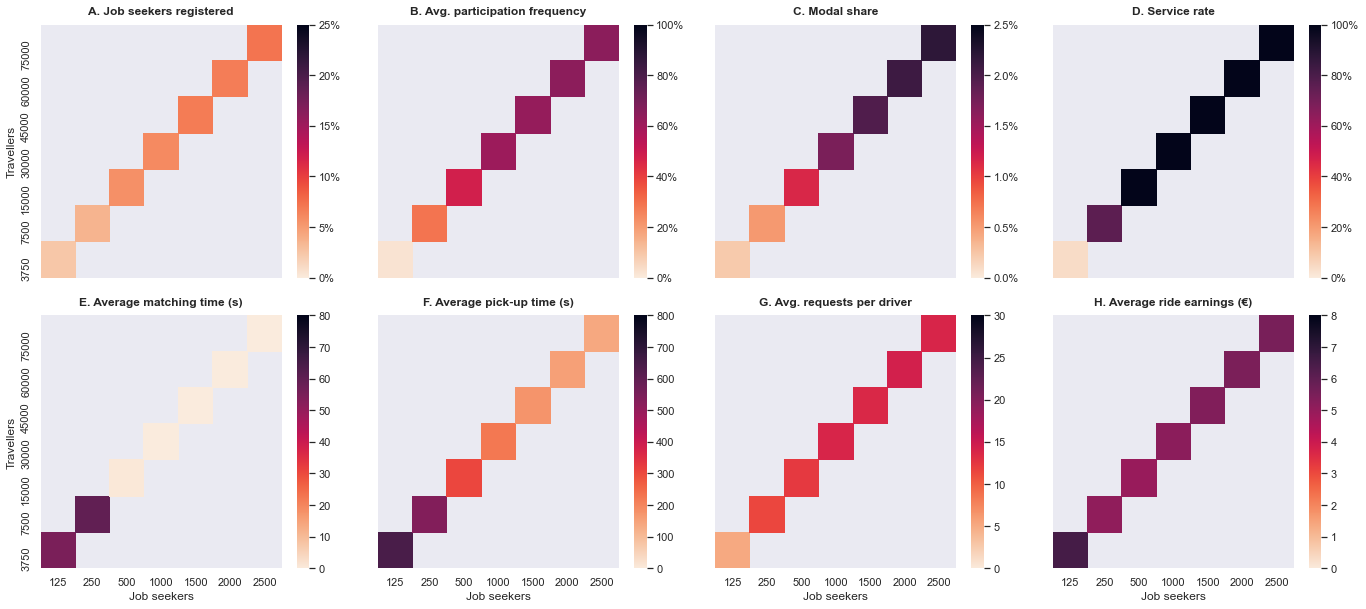

In [27]:
cmap = sns.cm.rocket_r
sns.set(font_scale=1.)
plt.rcParams['font.weight'] = "normal"
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(2, 4, figsize = [24,10], sharex=True, sharey=True)
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.15, wspace=0.12, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[2,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,3], cmap=cmap)
# axes[2,3].set_title('Participation rel. to job seekers')
# axes[2,3].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.sup.particip / res_proc.nP
# axes[2,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,2], cmap=cmap)
# axes[2,2].set_title('Participation rel. to travellers')
# axes[2,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

res_proc['mode_share'] = eql_scn.dem.requests / eql_scn.dem.nP # eql_scn.dem.inform
axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='mode_share'), ax = axes[0,2], cmap=cmap, vmin=0, vmax=0.025)
cbar = axes[0,2].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 1))
axes[0,2].set_title('C. Modal share', fontweight="bold", pad=10)
axes[0,2].invert_yaxis()
axes[0,2].set_xlabel('Job seekers')
axes[0,2].set_ylabel('Travellers')
axes[0,2].xaxis.label.set_visible(False)
axes[0,2].yaxis.label.set_visible(False)
# axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='exp_inc'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average daily driver earnings (euro)')
# axes[0,2].invert_yaxis()

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[1,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[1,3], cmap=cmap, vmin=0.0, vmax=8.0)
axes[1,3].set_title('H. Average ride earnings (\u20ac)', fontweight="bold", pad=10)
axes[1,3].invert_yaxis()
axes[1,3].set_xlabel('Job seekers')
axes[1,3].set_ylabel('Travellers')
axes[1,3].yaxis.label.set_visible(False)

res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[1,2], cmap=cmap, vmin=0, vmax=30)
axes[1,2].set_title('G. Avg. requests per driver', fontweight="bold", pad=10)
axes[1,2].invert_yaxis()
axes[1,2].set_xlabel('Job seekers')
axes[1,2].set_ylabel('Travellers')
axes[1,2].yaxis.label.set_visible(False)

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Average time between request and pick-up')
# axes[1,1].invert_yaxis()

res_proc['regist'] = eql_scn.sup.regist / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='regist'), ax = axes[0,0], cmap=cmap, vmin=0, vmax=0.25)
cbar = axes[0,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,0].set_title('A. Job seekers registered', fontweight="bold", pad=10)
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel('Job seekers')
axes[0,0].set_ylabel('Travellers')
axes[0,0].xaxis.label.set_visible(False)

res_proc['ptcp_prob'] = eql_scn.sup.particip / eql_scn.sup.regist
axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='ptcp_prob'), ax = axes[0,1], cmap=cmap, vmin=0, vmax=1)
cbar = axes[0,1].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,1].set_title('B. Avg. participation frequency', fontweight="bold", pad=10)
axes[0,1].invert_yaxis()
axes[0,1].set_xlabel('Job seekers')
axes[0,1].set_ylabel('Travellers')
axes[0,1].xaxis.label.set_visible(False)
axes[0,1].yaxis.label.set_visible(False)

res_proc['match_rate'] = eql_scn.dem.gets_offer.copy()
axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_rate'), ax = axes[0,3], cmap=cmap, vmin=0, vmax=1)
cbar = axes[0,3].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,3].set_title('D. Service rate', fontweight="bold", pad=10)
axes[0,3].invert_yaxis()
axes[0,3].set_xlabel('Job seekers')
axes[0,3].set_ylabel('Travellers')
axes[0,3].xaxis.label.set_visible(False)
axes[0,3].yaxis.label.set_visible(False)

res_proc['match_time'] = eql_scn.dem.match_time.copy()
axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_time'), ax = axes[1,0], cmap=cmap, vmin=0, vmax=80)
axes[1,0].set_title('E. Average matching time (s)', fontweight="bold", pad=10)
axes[1,0].invert_yaxis()
axes[1,0].set_xlabel('Job seekers')
axes[1,0].set_ylabel('Travellers')

res_proc['pickup_time'] = eql_scn.dem.pickup_time.copy()
axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='pickup_time'), ax = axes[1,1], cmap=cmap, vmin=0, vmax=800)
axes[1,1].set_title('F. Average pick-up time (s)', fontweight="bold", pad=10)
axes[1,1].invert_yaxis()
axes[1,1].set_xlabel('Job seekers')
axes[1,1].set_ylabel('Travellers')
axes[1,1].yaxis.label.set_visible(False)

# res_proc['req_per_driver'] = eql_scn.sup.particip / eql_scn.dem.requests
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_per_driver'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Participating drivers per request')
# axes[2,0].invert_yaxis()
# res_proc = pd.DataFrame(index = eql_scn.sup.index)
# res_proc['nP'] = eql_scn.sup.nP
# res_proc['nV'] = eql_scn.sup.nV

# res_proc['req_part'] = eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_part'), ax = axes[0,0], cmap=cmap)
# axes[0,0].set_title('Incoming requests per participating driver')
# axes[0,0].invert_yaxis()

# res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[0,3], cmap=cmap)
# axes[0,3].set_title('Satisfied requests per participating driver')
# axes[0,3].invert_yaxis()

# res_proc['earn_req'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / eql_scn.dem.requests
# axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req'), ax = axes[0,1], cmap=cmap)
# axes[0,1].set_title('Average earnings per request')
# axes[0,1].invert_yaxis()

# res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
# axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[1,0], cmap=cmap)
# axes[1,0].set_title('Average earnings per satisfied request')
# axes[1,0].invert_yaxis()

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average waiting time for pick-up')
# axes[0,2].invert_yaxis()

# res_proc['part_trav'] = eql_scn.sup.particip / eql_scn.dem.inform
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_trav'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Participating drivers per traveller')
# axes[1,1].invert_yaxis()

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
# axes[1,2].set_title('Participation rel. to job seekers')
# axes[1,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
# axes[1,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,3], cmap=cmap)
# axes[1,3].set_title('Mode share of ridesourcing')
# axes[1,3].invert_yaxis()
# # axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['reg_inf'] = eql_scn.sup.regist / eql_scn.sup.inform
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='reg_inf'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Share of job seekers registered with platform')
# axes[2,0].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))

# i = 0
# j = 0
# for kpi in kpis_sup:
#     axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_dem:
#     axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_plf:
#     axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1
        
# axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i])
# axes[j, i].set_title('soc_value')
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()

# from matplotlib.patches import Rectangle, Polygon, Patch
# array = np.array([[0,0],[7,0],[7,1],[2,1],[2,2],[0,2]])
# axes[1,0].add_patch(Polygon(array, closed=True, linewidth=-5, ec='y', fill=False))

# legend_elements = [Patch(facecolor="None", linewidth=3, edgecolor='y', 
#                          label='Pareto efficient strategy')]

# fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'msize_heat_main.jpg'),dpi=300,bbox_inches='tight')

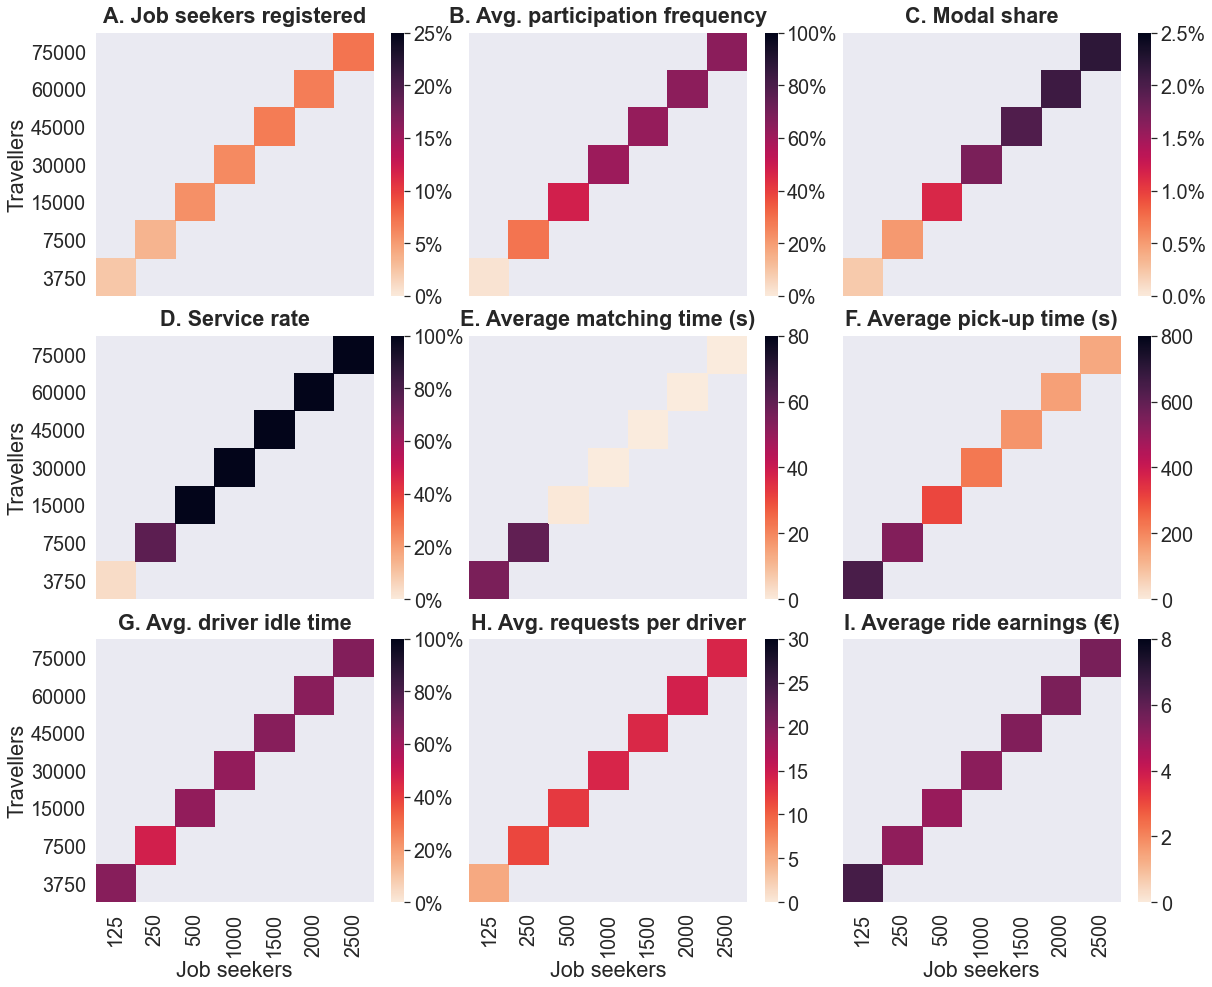

In [28]:
cmap = sns.cm.rocket_r
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(3, 3, figsize = [20,16], sharex=True, sharey=True)
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.15, wspace=0.075, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[2,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,3], cmap=cmap)
# axes[2,3].set_title('Participation rel. to job seekers')
# axes[2,3].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.sup.particip / res_proc.nP
# axes[2,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[2,2], cmap=cmap)
# axes[2,2].set_title('Participation rel. to travellers')
# axes[2,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

res_proc['mode_share'] = eql_scn.dem.requests / eql_scn.dem.nP # eql_scn.dem.inform
axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='mode_share'), ax = axes[0,2], cmap=cmap, vmin=0, vmax=0.025)
cbar = axes[0,2].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 1))
axes[0,2].set_title('C. Modal share', fontweight="bold", pad=10)
axes[0,2].invert_yaxis()
axes[0,2].set_xlabel('Job seekers')
axes[0,2].set_ylabel('Travellers')
axes[0,2].xaxis.label.set_visible(False)
axes[0,2].yaxis.label.set_visible(False)
# axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='exp_inc'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average daily driver earnings (euro)')
# axes[0,2].invert_yaxis()

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[2,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[2,2], cmap=cmap, vmin=0.0, vmax=8.0)
axes[2,2].set_title('I. Average ride earnings (\u20ac)', fontweight="bold", pad=10)
axes[2,2].invert_yaxis()
axes[2,2].set_xlabel('Job seekers')
axes[2,2].set_ylabel('Travellers')
axes[2,2].yaxis.label.set_visible(False)

res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[2,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[2,1], cmap=cmap, vmin=0, vmax=30)
axes[2,1].set_title('H. Avg. requests per driver', fontweight="bold", pad=10)
axes[2,1].invert_yaxis()
axes[2,1].set_xlabel('Job seekers')
axes[2,1].set_ylabel('Travellers')
axes[2,1].yaxis.label.set_visible(False)

res_proc['idle_time'] = eql_scn.sup.share_idle_time
axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='idle_time'), ax = axes[2,0], cmap=cmap, vmin=0, vmax=1)
axes[2,0].set_title('G. Avg. driver idle time', fontweight="bold", pad=10)
cbar = axes[2,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[2,0].invert_yaxis()
axes[2,0].set_xlabel('Job seekers')
axes[2,0].set_ylabel('Travellers')
# axes[2,0].yaxis.label.set_visible(False)

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Average time between request and pick-up')
# axes[1,1].invert_yaxis()

res_proc['regist'] = eql_scn.sup.regist / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='regist'), ax = axes[0,0], cmap=cmap, vmin=0, vmax=0.25)
cbar = axes[0,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,0].set_title('A. Job seekers registered', fontweight="bold", pad=10)
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel('Job seekers')
axes[0,0].set_ylabel('Travellers')
axes[0,0].xaxis.label.set_visible(False)

res_proc['ptcp_prob'] = eql_scn.sup.particip / eql_scn.sup.regist
axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='ptcp_prob'), ax = axes[0,1], cmap=cmap, vmin=0, vmax=1)
cbar = axes[0,1].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,1].set_title('B. Avg. participation frequency', fontweight="bold", pad=10)
axes[0,1].invert_yaxis()
axes[0,1].set_xlabel('Job seekers')
axes[0,1].set_ylabel('Travellers')
axes[0,1].xaxis.label.set_visible(False)
axes[0,1].yaxis.label.set_visible(False)

res_proc['match_rate'] = eql_scn.dem.gets_offer.copy()
axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_rate'), ax = axes[1,0], cmap=cmap, vmin=0, vmax=1)
cbar = axes[1,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[1,0].set_title('D. Service rate', fontweight="bold", pad=10)
axes[1,0].invert_yaxis()
axes[1,0].set_xlabel('Job seekers')
axes[1,0].set_ylabel('Travellers')
axes[1,0].xaxis.label.set_visible(False)
# axes[1,0].yaxis.label.set_visible(False)

res_proc['match_time'] = eql_scn.dem.match_time.copy()
axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_time'), ax = axes[1,1], cmap=cmap, vmin=0, vmax=80)
axes[1,1].set_title('E. Average matching time (s)', fontweight="bold", pad=10)
axes[1,1].invert_yaxis()
axes[1,1].set_xlabel('Job seekers')
axes[1,1].set_ylabel('Travellers')
axes[1,1].xaxis.label.set_visible(False)
axes[1,1].yaxis.label.set_visible(False)

res_proc['pickup_time'] = eql_scn.dem.pickup_time.copy()
axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='pickup_time'), ax = axes[1,2], cmap=cmap, vmin=0, vmax=800)
axes[1,2].set_title('F. Average pick-up time (s)', fontweight="bold", pad=10)
axes[1,2].invert_yaxis()
axes[1,2].set_xlabel('Job seekers')
axes[1,2].set_ylabel('Travellers')
axes[1,2].yaxis.label.set_visible(False)
axes[1,2].xaxis.label.set_visible(False)

# res_proc['req_per_driver'] = eql_scn.sup.particip / eql_scn.dem.requests
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_per_driver'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Participating drivers per request')
# axes[2,0].invert_yaxis()
# res_proc = pd.DataFrame(index = eql_scn.sup.index)
# res_proc['nP'] = eql_scn.sup.nP
# res_proc['nV'] = eql_scn.sup.nV

# res_proc['req_part'] = eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_part'), ax = axes[0,0], cmap=cmap)
# axes[0,0].set_title('Incoming requests per participating driver')
# axes[0,0].invert_yaxis()

# res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[0,3], cmap=cmap)
# axes[0,3].set_title('Satisfied requests per participating driver')
# axes[0,3].invert_yaxis()

# res_proc['earn_req'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / eql_scn.dem.requests
# axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req'), ax = axes[0,1], cmap=cmap)
# axes[0,1].set_title('Average earnings per request')
# axes[0,1].invert_yaxis()

# res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
# axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[1,0], cmap=cmap)
# axes[1,0].set_title('Average earnings per satisfied request')
# axes[1,0].invert_yaxis()

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average waiting time for pick-up')
# axes[0,2].invert_yaxis()

# res_proc['part_trav'] = eql_scn.sup.particip / eql_scn.dem.inform
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_trav'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Participating drivers per traveller')
# axes[1,1].invert_yaxis()

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
# axes[1,2].set_title('Participation rel. to job seekers')
# axes[1,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
# axes[1,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,3], cmap=cmap)
# axes[1,3].set_title('Mode share of ridesourcing')
# axes[1,3].invert_yaxis()
# # axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['reg_inf'] = eql_scn.sup.regist / eql_scn.sup.inform
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='reg_inf'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Share of job seekers registered with platform')
# axes[2,0].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))

# i = 0
# j = 0
# for kpi in kpis_sup:
#     axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_dem:
#     axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_plf:
#     axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1
        
# axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i])
# axes[j, i].set_title('soc_value')
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()

# from matplotlib.patches import Rectangle, Polygon, Patch
# array = np.array([[0,0],[7,0],[7,1],[2,1],[2,2],[0,2]])
# axes[1,0].add_patch(Polygon(array, closed=True, linewidth=-5, ec='y', fill=False))

# legend_elements = [Patch(facecolor="None", linewidth=3, edgecolor='y', 
#                          label='Pareto efficient strategy')]

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'msize_heat_main.jpg'),dpi=300,bbox_inches='tight')

In [29]:
# res_proc.loc[res_proc['match_rate'] < 0.95]
res_proc

,nP,nV,mode_share,earn_req_sat,serv_req_part,idle_time,regist,ptcp_prob,match_rate,match_time,pickup_time
scenario,,,,,,,,,,,
15000_500,15000,500,0.011496,4.967797,12.418230,0.636463,0.057360,0.483961,0.999565,0.722450,308.062692
30000_1000,30000,1000,0.017209,5.216465,13.933808,0.631011,0.060720,0.610013,0.999667,-1.215158,227.867154
3750_125,3750,125,0.002156,6.538567,5.117785,0.659203,0.024366,0.020638,0.039785,55.189385,644.489504
45000_1500,45000,1500,0.019740,5.389614,13.699568,0.659163,0.068907,0.627322,1.000000,-1.569925,176.969220
60000_2000,60000,2000,0.020996,5.479780,14.302452,0.653180,0.068240,0.645369,1.000000,-1.559352,155.764176
75000_2500,75000,2500,0.021990,5.540589,13.896528,0.670778,0.072896,0.651229,1.000000,-1.574441,137.640020
7500_250,7500,250,0.005180,5.116763,11.509965,0.483830,0.035400,0.290395,0.761406,59.855325,535.140641


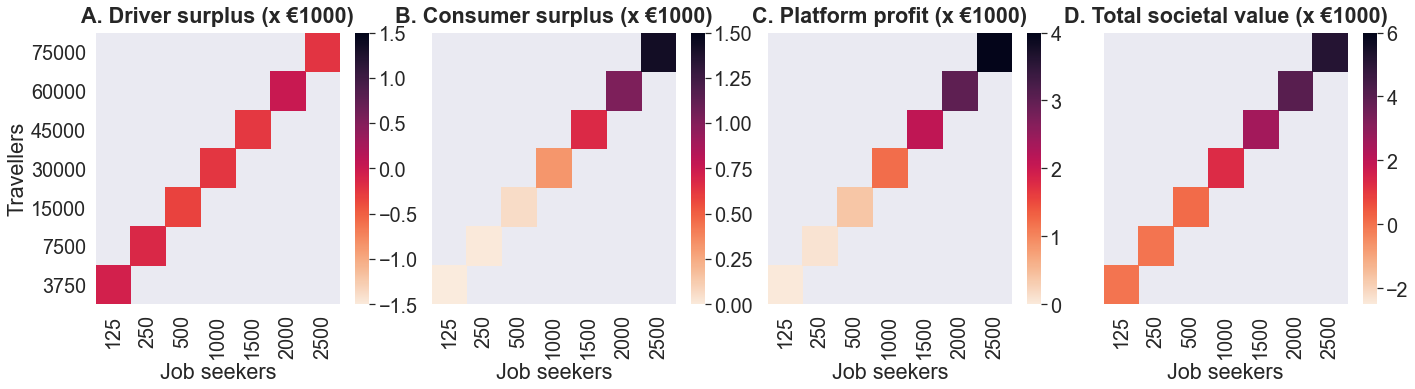

In [30]:
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 4, figsize = [24,5],sharey=True)
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.1, left=.12, right=.88)

axes[0] = sns.heatmap(eql_scn.sup.pivot(index=variable_1['name'], columns=variable_2['name'], values='driver_surplus')/1000, ax = axes[0], cmap=cmap, vmin=-1.5, vmax=1.5, cbar_kws={"ticks":[-1.5,-1,-0.5,0,0.5,1,1.5]})
axes[0].set_title('A. Driver surplus (x \u20ac1000)',fontweight="bold", pad=10)
axes[0].invert_yaxis()
axes[0].set_ylabel('Travellers')
axes[0].set_xlabel('Job seekers')
# axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(10))

axes[1] = sns.heatmap(eql_scn.dem.pivot(index=variable_1['name'], columns=variable_2['name'], values='cons_surplus')/1000, ax = axes[1], cmap=cmap, vmin=0, vmax=1.5)
axes[1].set_title('B. Consumer surplus (x \u20ac1000)',fontweight="bold", pad=10)
axes[1].invert_yaxis()
axes[1].set_ylabel('Travellers')
axes[1].set_xlabel('Job seekers')
axes[1].yaxis.label.set_visible(False)

axes[2] = sns.heatmap(eql_scn.plf.pivot(index=variable_1['name'], columns=variable_2['name'], values='plat_profit')/1000, ax = axes[2], cmap=cmap, vmin=0, vmax=4)
axes[2].set_title('C. Platform profit (x \u20ac1000)',fontweight="bold", pad=10)
axes[2].invert_yaxis()
axes[2].set_ylabel('Travellers')
axes[2].set_xlabel('Job seekers')
axes[2].yaxis.label.set_visible(False)

axes[3] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values='soc_value')/1000, ax = axes[3], cmap=cmap, vmin=-2.5, vmax=6)
axes[3].set_title('D. Total societal value (x \u20ac1000)',fontweight="bold", pad=10)
axes[3].invert_yaxis()
axes[3].set_ylabel('Travellers')
axes[3].set_xlabel('Job seekers')
axes[3].yaxis.label.set_visible(False)

# eql_scn.sup['rel_driv_surplus'] = eql_scn.sup.driver_surplus / eql_scn.sup.nV
# eql_scn.dem['rel_cons_surplus'] = eql_scn.dem.cons_surplus / eql_scn.sup.nP

# axes[0] = sns.heatmap(eql_scn.sup.pivot(index=variable_1['name'], columns=variable_2['name'], values='rel_driv_surplus'), ax = axes[0], cmap=cmap)
# axes[0].set_title('Labour surplus per job seeker',fontweight="bold")
# axes[0].invert_yaxis()
# axes[0].set_xlabel('Job seekers')
# axes[0].set_ylabel('Travellers')
# # axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(10))

# axes[1] = sns.heatmap(eql_scn.dem.pivot(index=variable_1['name'], columns=variable_2['name'], values='rel_cons_surplus'), ax = axes[1], cmap=cmap)
# axes[1].set_title('Consumer surplus per traveller',fontweight="bold")
# axes[1].invert_yaxis()
# axes[1].set_xlabel('Job seekers')
# axes[1].set_ylabel('Travellers')

# axes[2] = sns.heatmap(eql_scn.plf.pivot(index=variable_1['name'], columns=variable_2['name'], values='plat_profit')/1000, ax = axes[2], cmap=cmap)
# axes[2].set_title('Platform profit (x \u20ac1000)',fontweight="bold")
# axes[2].invert_yaxis()
# axes[2].set_xlabel('Job seekers')
# axes[2].set_ylabel('Travellers')

# axes[3] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values='soc_value')/1000, ax = axes[3], cmap=cmap)
# axes[3].set_title('Total societal value (x \u20ac1000)',fontweight="bold")
# axes[3].invert_yaxis()
# axes[3].set_xlabel('Job seekers')
# axes[3].set_ylabel('Travellers')


# from matplotlib.patches import Rectangle
# axes[3].add_patch(Rectangle((1, 5), 5, 1, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 0), 1, 4, hatch='.', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((3, 0), 3, 6, hatch='\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((1, 4), 1, 1, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 0), 1, 4, hatch='\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 4), 1, 2, hatch='+', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 4), 1, 1, hatch='O', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((1, 0), 1, 4, linewidth=-5, ec='y', fill=False))

# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor="None", hatch='..', edgecolor='k',
#                          label='Pareto inefficient: increase per-kilometre fare'),
#                    Patch(facecolor="None", hatch='\\\\', edgecolor='k',
#                          label='Pareto inefficient: decrease per-kilometre fare'),
#                    Patch(facecolor="None", hatch='///', edgecolor='k', 
#                          label='Pareto inefficient: decrease commission rate'),
#                    Patch(facecolor="None", hatch='++', edgecolor='k', 
#                          label='Pareto inefficient: increase per-kilometre fare and decrease commission'),
#                    Patch(facecolor="None", hatch='OO', edgecolor='k', 
#                          label='Pareto inefficient: decrease per-kilometre fare and commission'),
#                    Patch(facecolor="None", linewidth=3, edgecolor='y', 
#                          label='Pareto efficient')]
# axes[3].legend(handles=legend_elements, loc='center')

# axes[3].add_patch(Rectangle((1, 0), 1, 4, linewidth=-5, ec='y', fill=False))
# axes[3].add_patch(Rectangle((0, 0), 1, 6, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 0), 4, 6, hatch='\\\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 4), 6, 2, hatch='--', linewidth=0, ec='k', fill=False))
# # axes[3].add_patch(Rectangle((1, 4), 1, 1, hatch='//', linewidth=0, ec='k', fill=False))
# # axes[3].add_patch(Rectangle((2, 0), 1, 4, hatch='\\', linewidth=0, ec='k', fill=False))
# # axes[3].add_patch(Rectangle((0, 4), 1, 2, hatch='+', linewidth=0, ec='k', fill=False))
# # axes[3].add_patch(Rectangle((2, 4), 1, 1, hatch='O', linewidth=0, ec='k', fill=False))


# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor="None", linewidth=3, edgecolor='y', 
#                          label='Pareto efficient'),
#                    Patch(facecolor="None", hatch='///', edgecolor='k',
#                          label='Per-kilometre fare too low'),
#                    Patch(facecolor="None", hatch='\\\\\\', edgecolor='k',
#                          label='Per-kilometre fare too high'),
#                    Patch(facecolor="None", hatch='---', edgecolor='k', 
#                          label='Commission rate too high')]
# axes[3].legend(handles=legend_elements,fontsize=12, loc='center', bbox_to_anchor=(0.5, -0.35))

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'msize_heat_soc.jpg'.format(variable_1["name"],variable_2["name"])),dpi=300,bbox_inches='tight')

In [31]:
eql_scn.soc.soc_value.min()
eql_scn.sup.keys()

Index(['inform', 'regist', 'rejected_reg', 'particip', 'reject_particip',
       'mean_perc_inc', 'mean_perc_inc_ptcp', 'mean_perc_inc_reg',
       'mean_exp_inc', 'rel_perc_inc', 'rel_perc_inc_reg', 'rel_perc_inc_ptcp',
       'std_perc_inc', 'std_exp_inc', 'std_perc_inc_reg', 'std_perc_inc_ptcp',
       'res_wage_inf', 'res_wage_reg', 'res_wage_ptcp', 'new_regist',
       'deregist', 'driver_surplus', 'mean_rev', 'mean_op_costs', 'ivt_costs',
       'dh_costs', 'mean_dh_dist', 'mean_dh_time', 'drive_time',
       'not_idle_time', 'share_idle_time', 'nP', 'nV'],
      dtype='object')

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


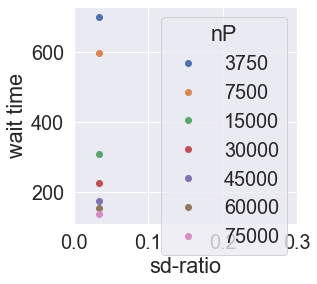

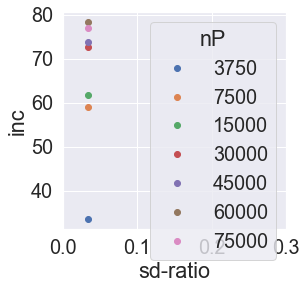

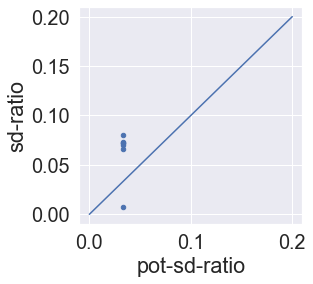

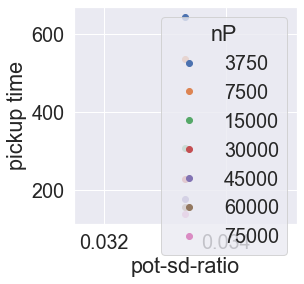

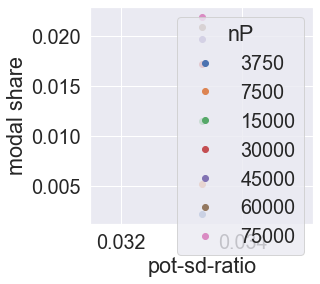

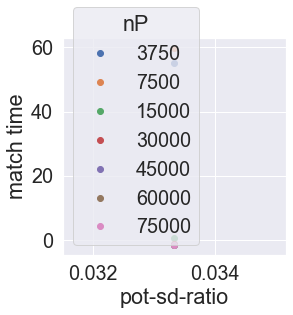

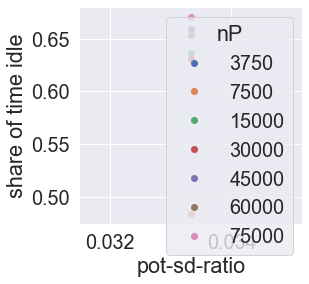

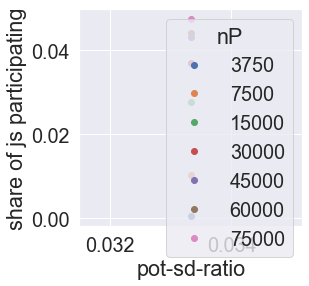

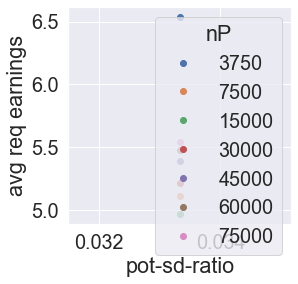

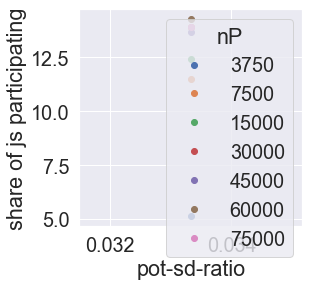

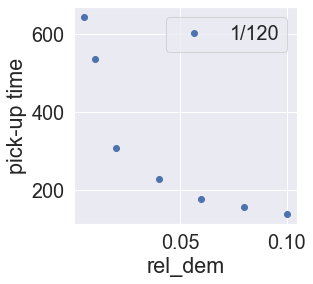

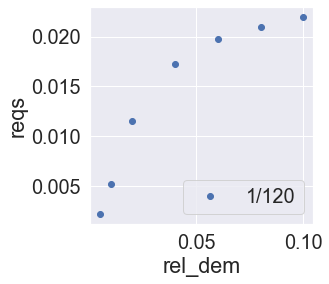

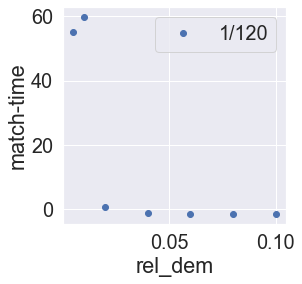

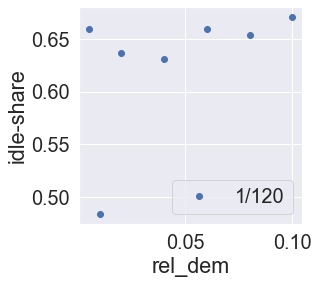

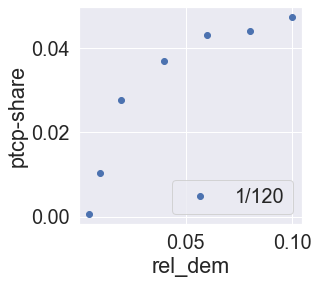

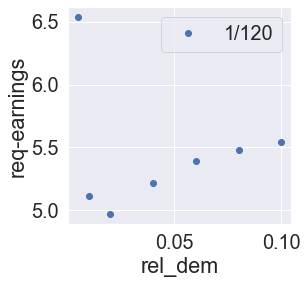

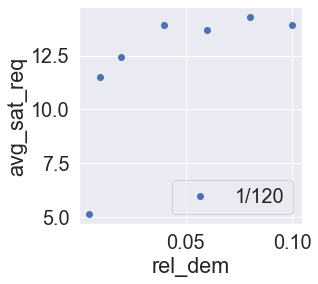

In [32]:
# eql_scn.dem.loc['3750_125']
eql_scn.dem['sd-ratio'] = eql_scn.dem.nV / eql_scn.sup.nP
eql_scn.sup['sd-ratio'] = eql_scn.dem.nV / eql_scn.sup.nP
df = eql_scn.dem.pivot(index='sd-ratio', columns='nP', values='mean_wait')
df2 = eql_scn.sup.pivot(index='sd-ratio', columns='nP', values='mean_exp_inc')
# # ax = df.plot(xticks=eql_scn.dem['sd-ratio'], ylabel='mean_wait')
ax = df.plot(ylabel='wait time',marker='o',linestyle='none')
ax2 = df2.plot(ylabel='inc',marker='o',linestyle='none')
ax.set_xlim(0,0.3)
ax2.set_xlim(0,0.3)

df3 = pd.DataFrame()
df3['pot-sd-ratio'] = eql_scn.dem.nV / eql_scn.sup.nP
df3['sd-ratio'] = eql_scn.sup.particip / eql_scn.dem.requests
ax3 = df3.plot.scatter(x='pot-sd-ratio',y='sd-ratio')
ax3.plot([0,0.2],[0,0.2])

df4 = pd.DataFrame()
df4['nP'] = eql_scn.sup.nP
df4['pot-sd-ratio'] = eql_scn.dem.nV / eql_scn.sup.nP
df4['pickup-time'] = eql_scn.dem.pickup_time
piv_1 = df4.pivot(index='pot-sd-ratio', columns='nP',values='pickup-time')
ax4 = piv_1.plot(ylabel='pickup time', marker='o',linestyle='none')
df4['reqs'] = eql_scn.dem.requests / eql_scn.sup.nP
piv_2 = df4.pivot(index='pot-sd-ratio', columns='nP',values='reqs')
ax5 = piv_2.plot(ylabel='modal share', marker='o',linestyle='none')
# df4['ratio_ptcp_req'] = eql_scn.dem.requests / eql_scn.sup.particip
# piv_3 = df4.pivot(index='pot-sd-ratio', columns='nP',values='ratio_ptcp_req')
# ax6 = piv_3.plot(ylabel='ratio req / ptcp', marker='o',linestyle='none')
df4['match-time'] = eql_scn.dem.match_time
piv_4 = df4.pivot(index='pot-sd-ratio', columns='nP',values='match-time')
ax7 = piv_4.plot(ylabel='match time', marker='o',linestyle='none')
df4['idle_share'] = eql_scn.sup.share_idle_time
piv_5 = df4.pivot(index='pot-sd-ratio', columns='nP',values='idle_share')
ax8 = piv_5.plot(ylabel='share of time idle', marker='o',linestyle='none')
df4['ptcp_share'] = eql_scn.sup.particip / eql_scn.dem.nV
piv_6 = df4.pivot(index='pot-sd-ratio', columns='nP',values='ptcp_share')
ax9 = piv_6.plot(ylabel='share of js participating', marker='o',linestyle='none')
df4['req_earnings'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
piv_7 = df4.pivot(index='pot-sd-ratio', columns='nP',values='req_earnings')
ax10 = piv_7.plot(ylabel='avg req earnings', marker='o',linestyle='none')
df4['avg_sat_req'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
piv_8 = df4.pivot(index='pot-sd-ratio', columns='nP',values='avg_sat_req')
ax11 = piv_8.plot(ylabel='share of js participating', marker='o',linestyle='none')

df4['nV'] = eql_scn.dem.nV
# df4['rel_sup'] = eql_scn.dem.nV / eql_scn.dem.nV.max() / 10
# df5 = df4.loc[df4['nP'] == 75000]
# df5 = df5.sort_values(by='nV')
# piv_8 = df4.pivot(index='rel_sup', columns='pot-sd-ratio',values='pickup-time')
# piv_8 = piv_8.loc[:,(~piv_8.isna()).sum() >= 3]
# ax11 = piv_8.plot(ylabel='pick-up time', marker='o', linestyle='none')
# ax11.legend(['1/120','1/60','1/30','1/15', '1/7.5'])
# ax11.get_legend().remove()
# ax11 = piv_8.plot(ylabel='share of js participating', marker='o')
# ax12 = df5.plot(x='rel_market_size',y='pickup-time',label='nP=75000')
# df6 = df4.loc[df4['pot-sd-ratio'] == (1/30)].sort_values(by='rel_market_size')
# df7 = df4.loc[df4['pot-sd-ratio'] == (1/30)].sort_values(by='rel_market_size')
# ax13 = df5.plot(x='rel_market_size',y='pickup-time',label='fixed ratio')
df4['rel_dem'] = eql_scn.dem.nP / eql_scn.dem.nP.max() / 10
piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='pickup-time')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax12 = piv_9.plot(ylabel='pick-up time', marker='o', linestyle='none')
ax12.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='reqs')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='reqs', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='match-time')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='match-time', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='idle_share')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='idle-share', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='ptcp_share')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='ptcp-share', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='req_earnings')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='req-earnings', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

piv_9 = df4.pivot(index='rel_dem', columns='pot-sd-ratio',values='avg_sat_req')
piv_9 = piv_9.loc[:,(~piv_9.isna()).sum() >= 3]
ax13 = piv_9.plot(ylabel='avg_sat_req', marker='o', linestyle='none')
ax13.legend(['1/120','1/60','1/30','1/15', '1/7.5'])

In [33]:
df

nP,3750,7500,15000,30000,45000,60000,75000
sd-ratio,,,,,,,
0.033333,699.678889,594.995965,308.785142,226.651997,175.399295,154.204825,136.065578


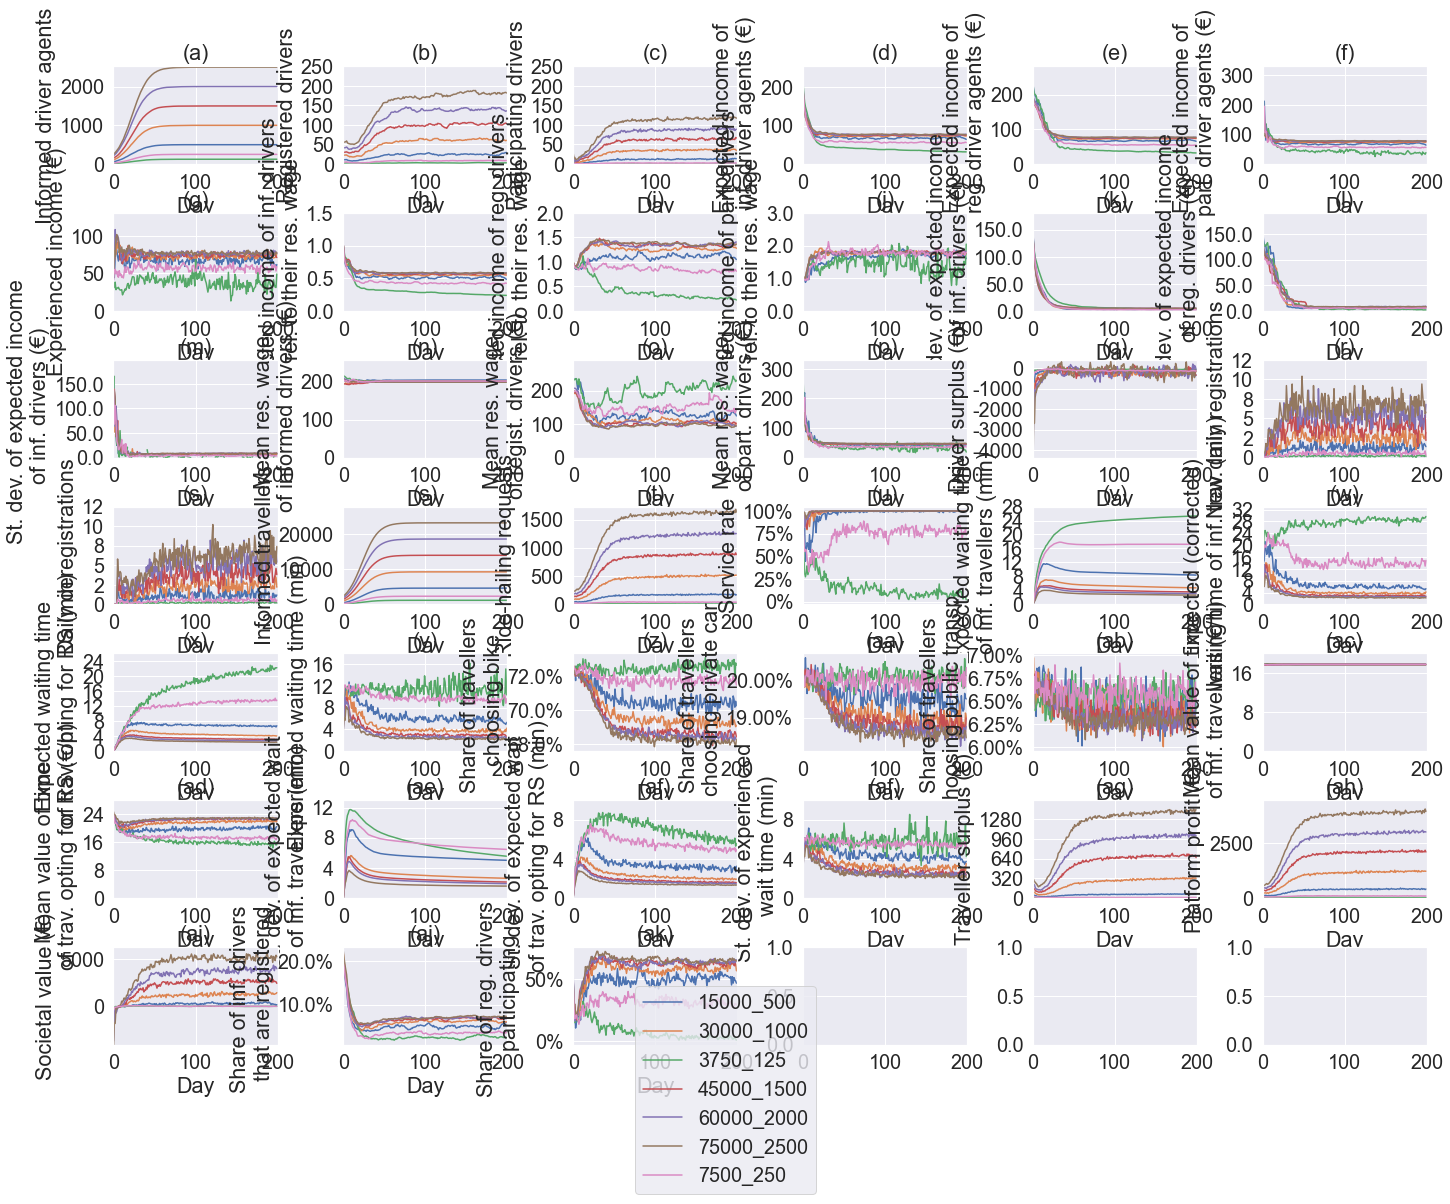

In [34]:
# Plot all indicators in one graph
fig = plot_multi_graph(res_scn, vals)
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'dynamics_multi_fig.jpg'),dpi=300,bbox_inches='tight')

In [109]:
eql_scn.sup

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,...,ivt_costs,dh_costs,mean_dh_dist,mean_dh_time,drive_time,not_idle_time,share_idle_time,nP,nV,sd-ratio
scenario,,,,,,,,,,,,,,,,,,,,,
15000_500,500.0,28.680000,0.0,13.880000,0.0,66.291138,66.620772,67.081467,61.691249,0.498743,...,16.381054,9.793643,39.174572,3917.457176,6552.421633,10469.878808,0.636463,15000,500,0.033333
30000_1000,1000.0,60.720000,0.0,37.040000,0.0,73.544354,74.513045,74.071604,72.685222,0.551105,...,18.560051,8.007175,32.028701,3202.870066,7424.020451,10626.890517,0.631011,30000,1000,0.033333
3750_125,125.0,3.045714,0.0,0.062857,0.0,31.792885,35.314551,32.152828,33.462979,0.237385,...,10.613971,13.923419,55.693675,5569.367500,4245.588333,9814.955833,0.659203,3750,125,0.033333
45000_1500,1500.0,103.360000,0.0,64.840000,0.0,75.279190,76.297308,75.195434,73.835387,0.569310,...,18.422321,6.117922,24.471687,2447.168669,7368.928306,9816.096975,0.659163,45000,1500,0.033333
60000_2000,2000.0,136.480000,0.0,88.080000,0.0,77.241606,78.414578,77.120110,78.374296,0.580997,...,19.381558,5.589458,22.357831,2235.783106,7752.623341,9988.406446,0.653180,60000,2000,0.033333
75000_2500,2500.0,182.240000,0.0,118.680000,0.0,76.588005,77.727358,76.920121,76.994954,0.577458,...,18.895458,4.808546,19.234183,1923.418275,7558.183305,9481.601581,0.670778,75000,2500,0.033333
7500_250,250.0,8.850000,0.0,2.570000,0.0,55.926127,55.287732,54.434442,58.893763,0.421146,...,17.803944,19.360331,77.441324,7744.132400,7121.577410,14865.709810,0.483830,7500,250,0.033333


In [46]:
res_scn.sup.regist

,15000_500,30000_1000,3750_125,45000_1500,60000_2000,75000_2500,7500_250
day,,,,,,,
0,11.0,22.6,2.571429,30.0,41.4,55.4,5.05
1,11.2,22.6,2.657143,30.0,41.6,55.8,5.20
2,11.2,23.0,2.657143,30.4,41.8,56.4,5.20
3,11.2,23.0,2.742857,31.0,42.4,57.2,5.25
4,11.4,23.2,2.857143,31.2,43.4,59.0,5.40
...,...,...,...,...,...,...,...
195,27.4,61.0,3.028571,101.6,138.4,181.2,8.95
196,28.2,61.6,3.057143,103.2,137.0,182.4,8.75
197,28.8,60.4,3.028571,104.0,136.0,182.8,8.60


In [72]:
sup_vol = []
dem_vol = []
for i in range(len(vals)):
    sup_vol.append(int(vals[i].split("_")[1])) 
    dem_vol.append(int(vals[i].split("_")[0]))

In [114]:
res_scn.sup.keys()
res_scn.sup.particip.rolling(3, min_periods=1).mean()

,15000_500,30000_1000,3750_125,45000_1500,60000_2000,75000_2500,7500_250
day,,,,,,,
0,5.400000,10.600000,1.228571,13.000000,22.400000,28.200000,2.600000
1,4.700000,8.800000,1.071429,11.300000,17.800000,22.000000,2.000000
2,4.000000,7.866667,0.847619,10.333333,14.133333,20.266667,1.650000
3,2.600000,6.200000,0.609524,8.133333,9.733333,14.866667,1.133333
4,1.866667,5.266667,0.466667,6.733333,8.066667,13.466667,1.050000
...,...,...,...,...,...,...,...
195,13.200000,37.733333,0.076190,63.933333,88.466667,118.400000,2.483333
196,13.866667,37.800000,0.066667,63.133333,89.066667,119.933333,2.433333
197,13.800000,37.933333,0.076190,63.200000,87.800000,119.133333,2.500000


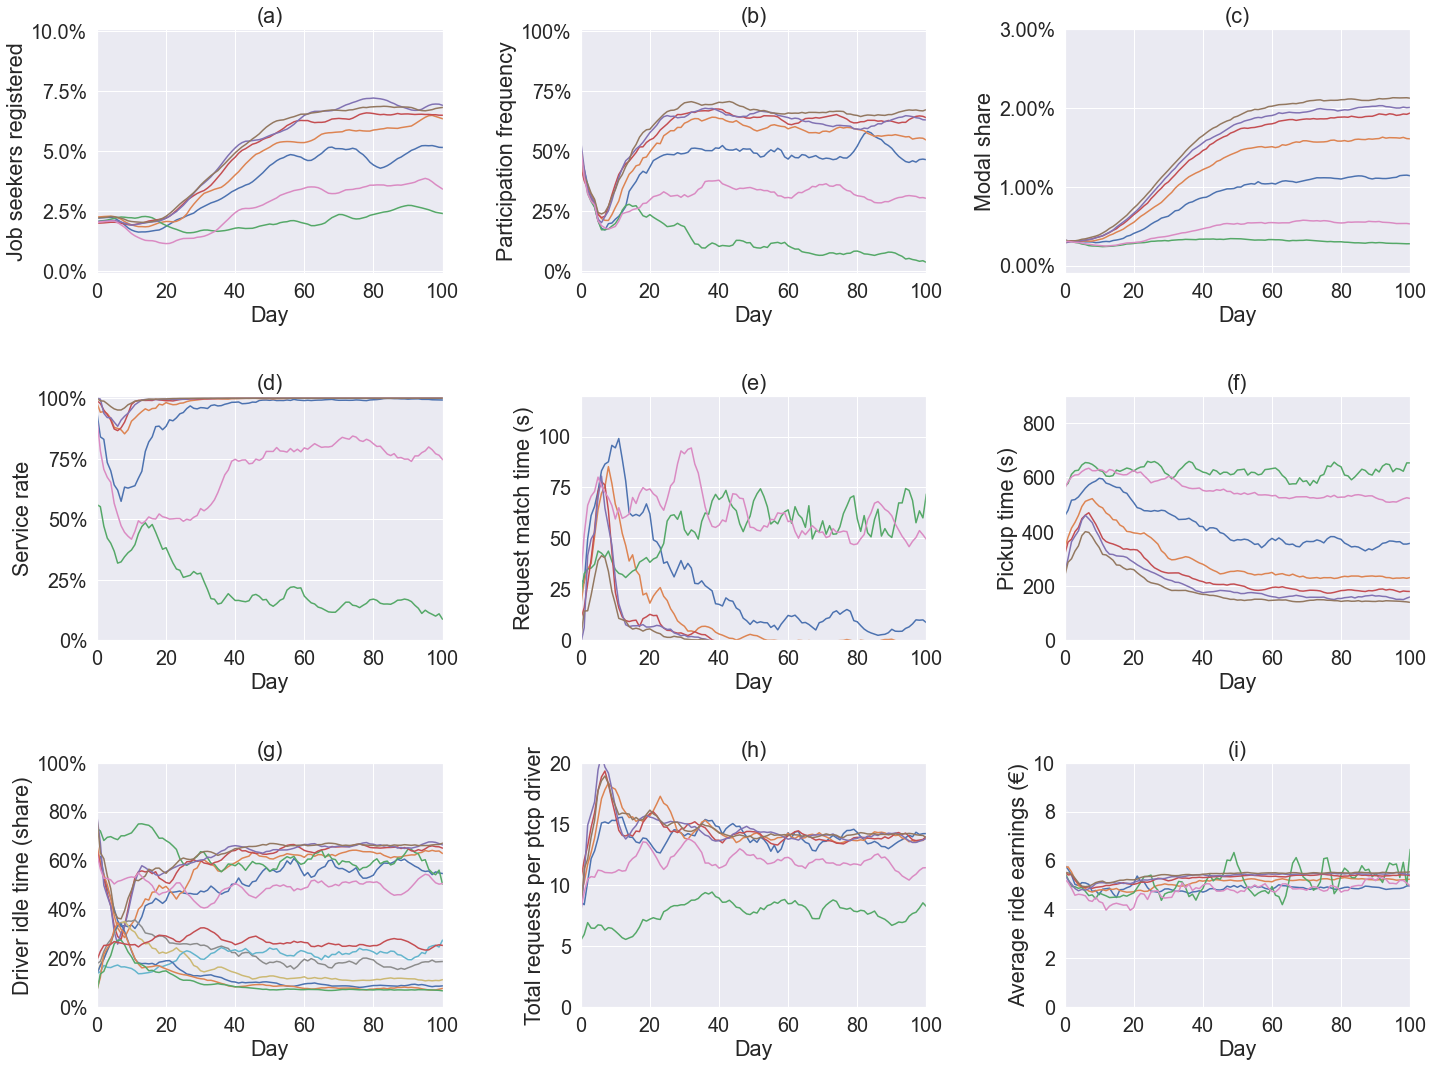

In [220]:
fig, axes = plt.subplots(3, 3, figsize = [24,18])
# plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)
plt.setp(axes, xlim=[0,100])

axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
axes[0, 0].set_ylabel('Job seekers registered')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_title('(a)')
axes[0, 0].set_ylim(bottom = -0.001, top = 0.101)
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[0, 0].locator_params(axis='y', nbins=5)

axes[0, 1].plot((res_scn.sup.particip / res_scn.sup.regist).rolling(5, min_periods=1).mean())
axes[0, 1].set_ylabel('Participation frequency')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_title('(b)')
axes[0, 1].set_ylim(bottom = -0.01, top = 1.01)
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 1].locator_params(axis='y', nbins=5)

axes[0, 2].plot(res_scn.dem.requests.rolling(5, min_periods=1).mean() / dem_vol)
axes[0, 2].set_ylabel('Modal share')
axes[0, 2].set_xlabel('Day')
axes[0, 2].set_title('(c)')
axes[0, 2].set_ylim(bottom = -0.001, top = 0.03)
axes[0, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 2].locator_params(axis='y', nbins=5)

axes[1, 0].plot(res_scn.dem.gets_offer.rolling(5, min_periods=1).mean())
axes[1, 0].set_ylabel('Service rate')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_title('(d)')
axes[1, 0].set_ylim(bottom = -0.001, top = 1.01)
axes[1, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 0].locator_params(axis='y', nbins=5)

axes[1, 1].plot(res_scn.dem.match_time.rolling(5, min_periods=1).mean())
axes[1, 1].set_ylabel('Request match time (s)')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_title('(e)')
axes[1, 1].set_ylim(bottom = 0, top = 120)
# axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[1, 1].locator_params(axis='y', nbins=5)

axes[1, 2].plot(res_scn.dem.pickup_time.rolling(5, min_periods=1).mean())
axes[1, 2].set_ylabel('Pickup time (s)')
axes[1, 2].set_xlabel('Day')
axes[1, 2].set_title('(f)')
axes[1, 2].set_ylim(bottom = 0, top = 900)
# axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[1, 2].locator_params(axis='y', nbins=5)

axes[2, 0].plot(res_scn.sup.share_idle_time.rolling(5, min_periods=1).mean())
axes[2, 0].set_ylabel('Driver idle time (share)')
axes[2, 0].set_xlabel('Day')
axes[2, 0].set_title('(g)')
axes[2, 0].set_ylim(bottom = 0, top = 1)
axes[2, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[2, 0].locator_params(axis='y', nbins=5)

axes[2, 1].plot((res_scn.dem.requests * res_scn.dem.gets_offer / res_scn.sup.particip).rolling(5, min_periods=1).mean())
axes[2, 1].set_ylabel('Total requests per ptcp driver')
axes[2, 1].set_xlabel('Day')
axes[2, 1].set_title('(h)')
axes[2, 1].set_ylim(bottom = 0, top = 20)
# axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[2, 1].locator_params(axis='y', nbins=5)

axes[2, 2].plot((res_scn.sup.mean_exp_inc / (res_scn.dem.requests / res_scn.sup.particip * res_scn.dem.gets_offer)).rolling(3, min_periods=1).mean())
axes[2, 2].set_ylabel('Average ride earnings (€)')
axes[2, 2].set_xlabel('Day')
axes[2, 2].set_title('(i)')
axes[2, 2].set_ylim(bottom = 0, top = 10)
# axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[2, 2].locator_params(axis='y', nbins=5)

In [221]:
res_proc
res_proc['match_time'] = res_proc['match_time'] / 60
res_proc['pickup_time'] = res_proc['pickup_time'] / 60
# res_proc.sort_values(by=['nV'])

,nP,nV,mode_share,earn_req_sat,serv_req_part,idle_time,regist,ptcp_prob,match_rate,match_time,pickup_time
scenario,,,,,,,,,,,
15000_500,15000,500,0.011496,4.967797,12.418230,0.636463,0.057360,0.483961,0.999565,0.012041,5.134378
30000_1000,30000,1000,0.017209,5.216465,13.933808,0.631011,0.060720,0.610013,0.999667,-0.020253,3.797786
3750_125,3750,125,0.002156,6.538567,5.117785,0.659203,0.024366,0.020638,0.039785,0.919823,10.741492
45000_1500,45000,1500,0.019740,5.389614,13.699568,0.659163,0.068907,0.627322,1.000000,-0.026165,2.949487
60000_2000,60000,2000,0.020996,5.479780,14.302452,0.653180,0.068240,0.645369,1.000000,-0.025989,2.596070
75000_2500,75000,2500,0.021990,5.540589,13.896528,0.670778,0.072896,0.651229,1.000000,-0.026241,2.294000
7500_250,7500,250,0.005180,5.116763,11.509965,0.483830,0.035400,0.290395,0.761406,0.997589,8.919011


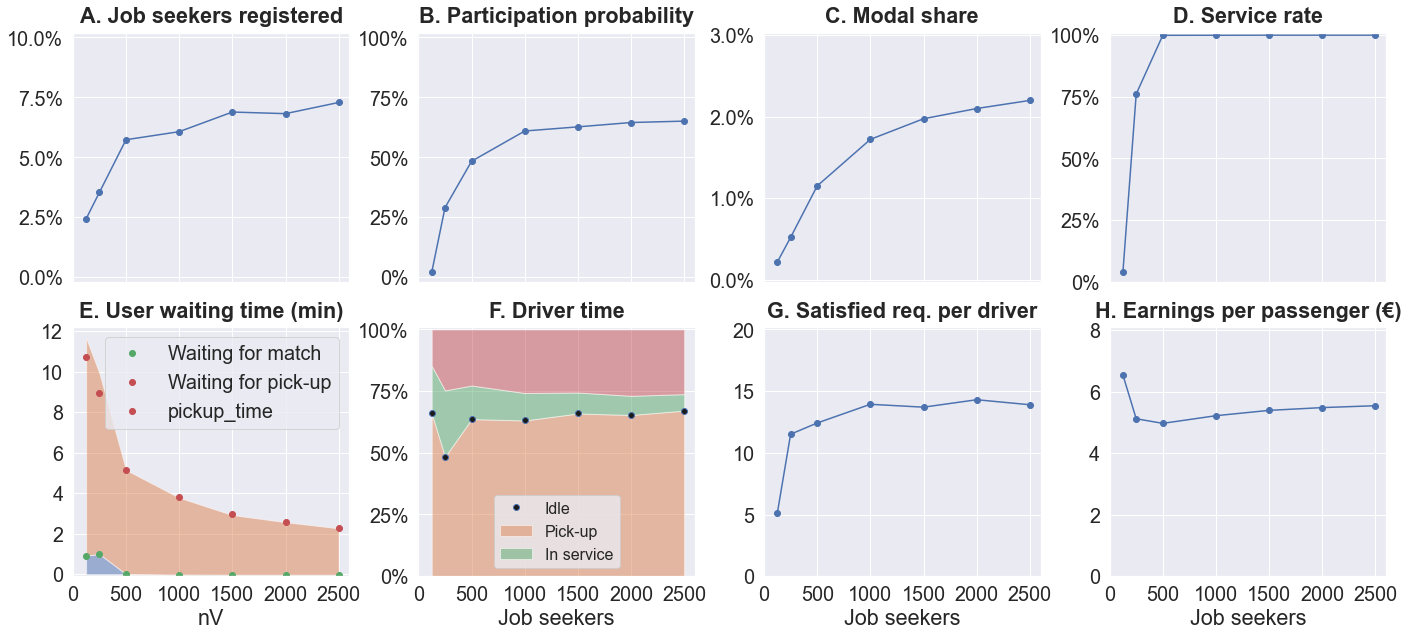

In [299]:
fig, axes = plt.subplots(2, 4, figsize = [24,10],sharex=True)
# plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.18, wspace=0.25, left=.12, right=.88)
plt.setp(axes, xlim=[0,2600],xticks=np.arange(0, 3000, step=500))
# locs, labels = plt.xticks()
# xticks(np.arange(0, 2500, step=500))


res_proc.sort_values(by=['nP']).plot(x='nV',y='regist',ax=axes[0,0],legend=None, marker='o')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[0, 0].set_ylabel('Job seekers registered')
axes[0, 0].set_xlabel('Job seekers')
axes[0, 0].set_title('A. Job seekers registered',fontweight="bold",pad=10)
axes[0, 0].set_ylim(bottom = -0.002, top = 0.102)
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[0, 0].locator_params(axis='y', nbins=5)

res_proc.sort_values(by=['nP']).plot(x='nV',y='ptcp_prob',ax=axes[0,1],legend=None, marker='o')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[0, 1].set_ylabel('Participation probability')
axes[0, 1].set_xlabel('nV')
axes[0, 1].set_title('B. Participation probability',fontweight="bold",pad=10)
axes[0, 1].set_ylim(bottom = -0.02, top = 1.02)
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[0, 1].locator_params(axis='y', nbins=5)

res_proc.sort_values(by=['nP']).plot(x='nV',y='mode_share',ax=axes[0,2],legend=None, marker='o')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[0, 2].set_ylabel('Modal share')
# axes[0, 2].set_xlabel('nV')
axes[0, 2].set_title('C. Modal share', fontweight="bold",pad=10)
axes[0, 2].set_ylim(bottom = -0.0003, top = 0.0303)
axes[0, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1,decimals=1)) 
axes[0, 2].locator_params(axis='y', nbins=4)

res_proc.sort_values(by=['nP']).plot(x='nV',y='match_rate',ax=axes[0,3],legend=None, marker='o')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[0, 3].set_ylabel('Service rate')
axes[0, 3].set_xlabel('nV')
axes[0, 3].set_title('D. Service rate', fontweight="bold",pad=10)
axes[0, 3].set_ylim(bottom = -0.001, top = 1.01)
axes[0, 3].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[0, 3].locator_params(axis='y', nbins=5)

# res_proc.sort_values(by=['nP']).plot(x='nV',y='match_time',ax=axes[1,0],label='Match time')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[1, 0].set_ylabel('E. User waiting time')
axes[1, 0].set_xlabel('Job seekers')
axes[1, 0].set_title('E. User waiting time (min)', fontweight="bold",pad=10)
axes[1, 0].set_ylim(bottom = -2, top = 100)
# axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[1, 0].locator_params(axis='y', nbins=5)

x = res_proc.sort_values(by=['nP'])['nV']
y1 = res_proc.sort_values(by=['nP'])['match_time']
y2 = res_proc.sort_values(by=['nP'])['pickup_time']
axes[1, 0].stackplot(x,y1,y2, alpha=0.5)
axes[1, 0].legend(['Waiting for match','Waiting for pick-up'],fontsize=16)



# axes[1, 0].set_ylabel('Pickup time')
axes[1, 0].set_xlabel('Job seekers')
# axes[1, 0].set_title('(f)')
axes[1, 0].set_ylim(bottom = -0.1, top = 12.2)
# axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[1, 0].locator_params(axis='y', nbins=7)

res_proc.sort_values(by=['nP']).plot(x='nV',y='match_time',ax=axes[1,0],marker='o',linestyle='')
res_proc.sort_values(by=['nP']).plot(x='nV',y='pickup_time',ax=axes[1,0],marker='o',linestyle='')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)



res_proc.sort_values(by=['nP']).plot(x='nV',y='idle_time',ax=axes[1,1], label='Idle',marker='o',linestyle='',mfc='k')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[1, 1].set_ylabel('Driver idle time')

res_proc['dh_time'] = eql_scn.sup.mean_dh_time / (params[0]['simTime'] * 3600)
# res_proc.sort_values(by=['nP']).plot(x='nV',y='dh_time',ax=axes[1,1], label='Pick-up')
x = res_proc.sort_values(by=['nP'])['nV']
y1 = res_proc.sort_values(by=['nP'])['idle_time']
y2 = res_proc.sort_values(by=['nP'])['dh_time']
y3 = 1 - y1 - y2
axes[1, 1].stackplot(x,y1,y2,y3, alpha=0.5)
axes[1, 1].legend(['Idle','Pick-up','In service'],loc='lower center',fontsize=16)



axes[1, 1].set_xlabel('Job seekers')
axes[1, 1].set_title('F. Driver time', fontweight="bold",pad=10)
axes[1, 1].set_ylim(bottom = -0.001, top = 1.01)
axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[1, 1].locator_params(axis='y', nbins=5)


# axes[1, 1].plot((res_scn.sup.mean_dh_time / (params[0]['simTime'] * 3600)).rolling(5, min_periods=1).mean(),label='Deadheading')

res_proc.sort_values(by=['nP']).plot(x='nV',y='serv_req_part',ax=axes[1,2],legend=None, marker='o')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[1, 2].set_ylabel('Satisfied requests per driver')
axes[1, 2].set_xlabel('Job seekers')
axes[1, 2].set_title('G. Satisfied req. per driver',fontweight="bold",pad=10)
axes[1, 2].set_ylim(bottom = -0.002, top = 20.2)
# axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[1, 2].locator_params(axis='y', nbins=5)

res_proc.sort_values(by=['nP']).plot(x='nV',y='earn_req_sat',ax=axes[1,3],legend=None, marker='o')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[1, 3].set_ylabel('Earnings per passenger')
axes[1, 3].set_xlabel('Job seekers')
axes[1, 3].set_title('H. Earnings per passenger (€)', fontweight="bold",pad=10)
axes[1, 3].set_ylim(bottom = -0.001, top = 8.1)
# axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[1, 3].locator_params(axis='y', nbins=5)

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'msize_fix-ratio.jpg'),dpi=300,bbox_inches='tight')

In [272]:
# res_proc
# x.sort()
x

In [138]:
eql_scn.sup

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,...,ivt_costs,dh_costs,mean_dh_dist,mean_dh_time,drive_time,not_idle_time,share_idle_time,nP,nV,sd-ratio
scenario,,,,,,,,,,,,,,,,,,,,,
15000_500,500.0,28.680000,0.0,13.880000,0.0,66.291138,66.620772,67.081467,61.691249,0.498743,...,16.381054,9.793643,39.174572,3917.457176,6552.421633,10469.878808,0.636463,15000,500,0.033333
30000_1000,1000.0,60.720000,0.0,37.040000,0.0,73.544354,74.513045,74.071604,72.685222,0.551105,...,18.560051,8.007175,32.028701,3202.870066,7424.020451,10626.890517,0.631011,30000,1000,0.033333
3750_125,125.0,3.045714,0.0,0.062857,0.0,31.792885,35.314551,32.152828,33.462979,0.237385,...,10.613971,13.923419,55.693675,5569.367500,4245.588333,9814.955833,0.659203,3750,125,0.033333
45000_1500,1500.0,103.360000,0.0,64.840000,0.0,75.279190,76.297308,75.195434,73.835387,0.569310,...,18.422321,6.117922,24.471687,2447.168669,7368.928306,9816.096975,0.659163,45000,1500,0.033333
60000_2000,2000.0,136.480000,0.0,88.080000,0.0,77.241606,78.414578,77.120110,78.374296,0.580997,...,19.381558,5.589458,22.357831,2235.783106,7752.623341,9988.406446,0.653180,60000,2000,0.033333
75000_2500,2500.0,182.240000,0.0,118.680000,0.0,76.588005,77.727358,76.920121,76.994954,0.577458,...,18.895458,4.808546,19.234183,1923.418275,7558.183305,9481.601581,0.670778,75000,2500,0.033333
7500_250,250.0,8.850000,0.0,2.570000,0.0,55.926127,55.287732,54.434442,58.893763,0.421146,...,17.803944,19.360331,77.441324,7744.132400,7121.577410,14865.709810,0.483830,7500,250,0.033333


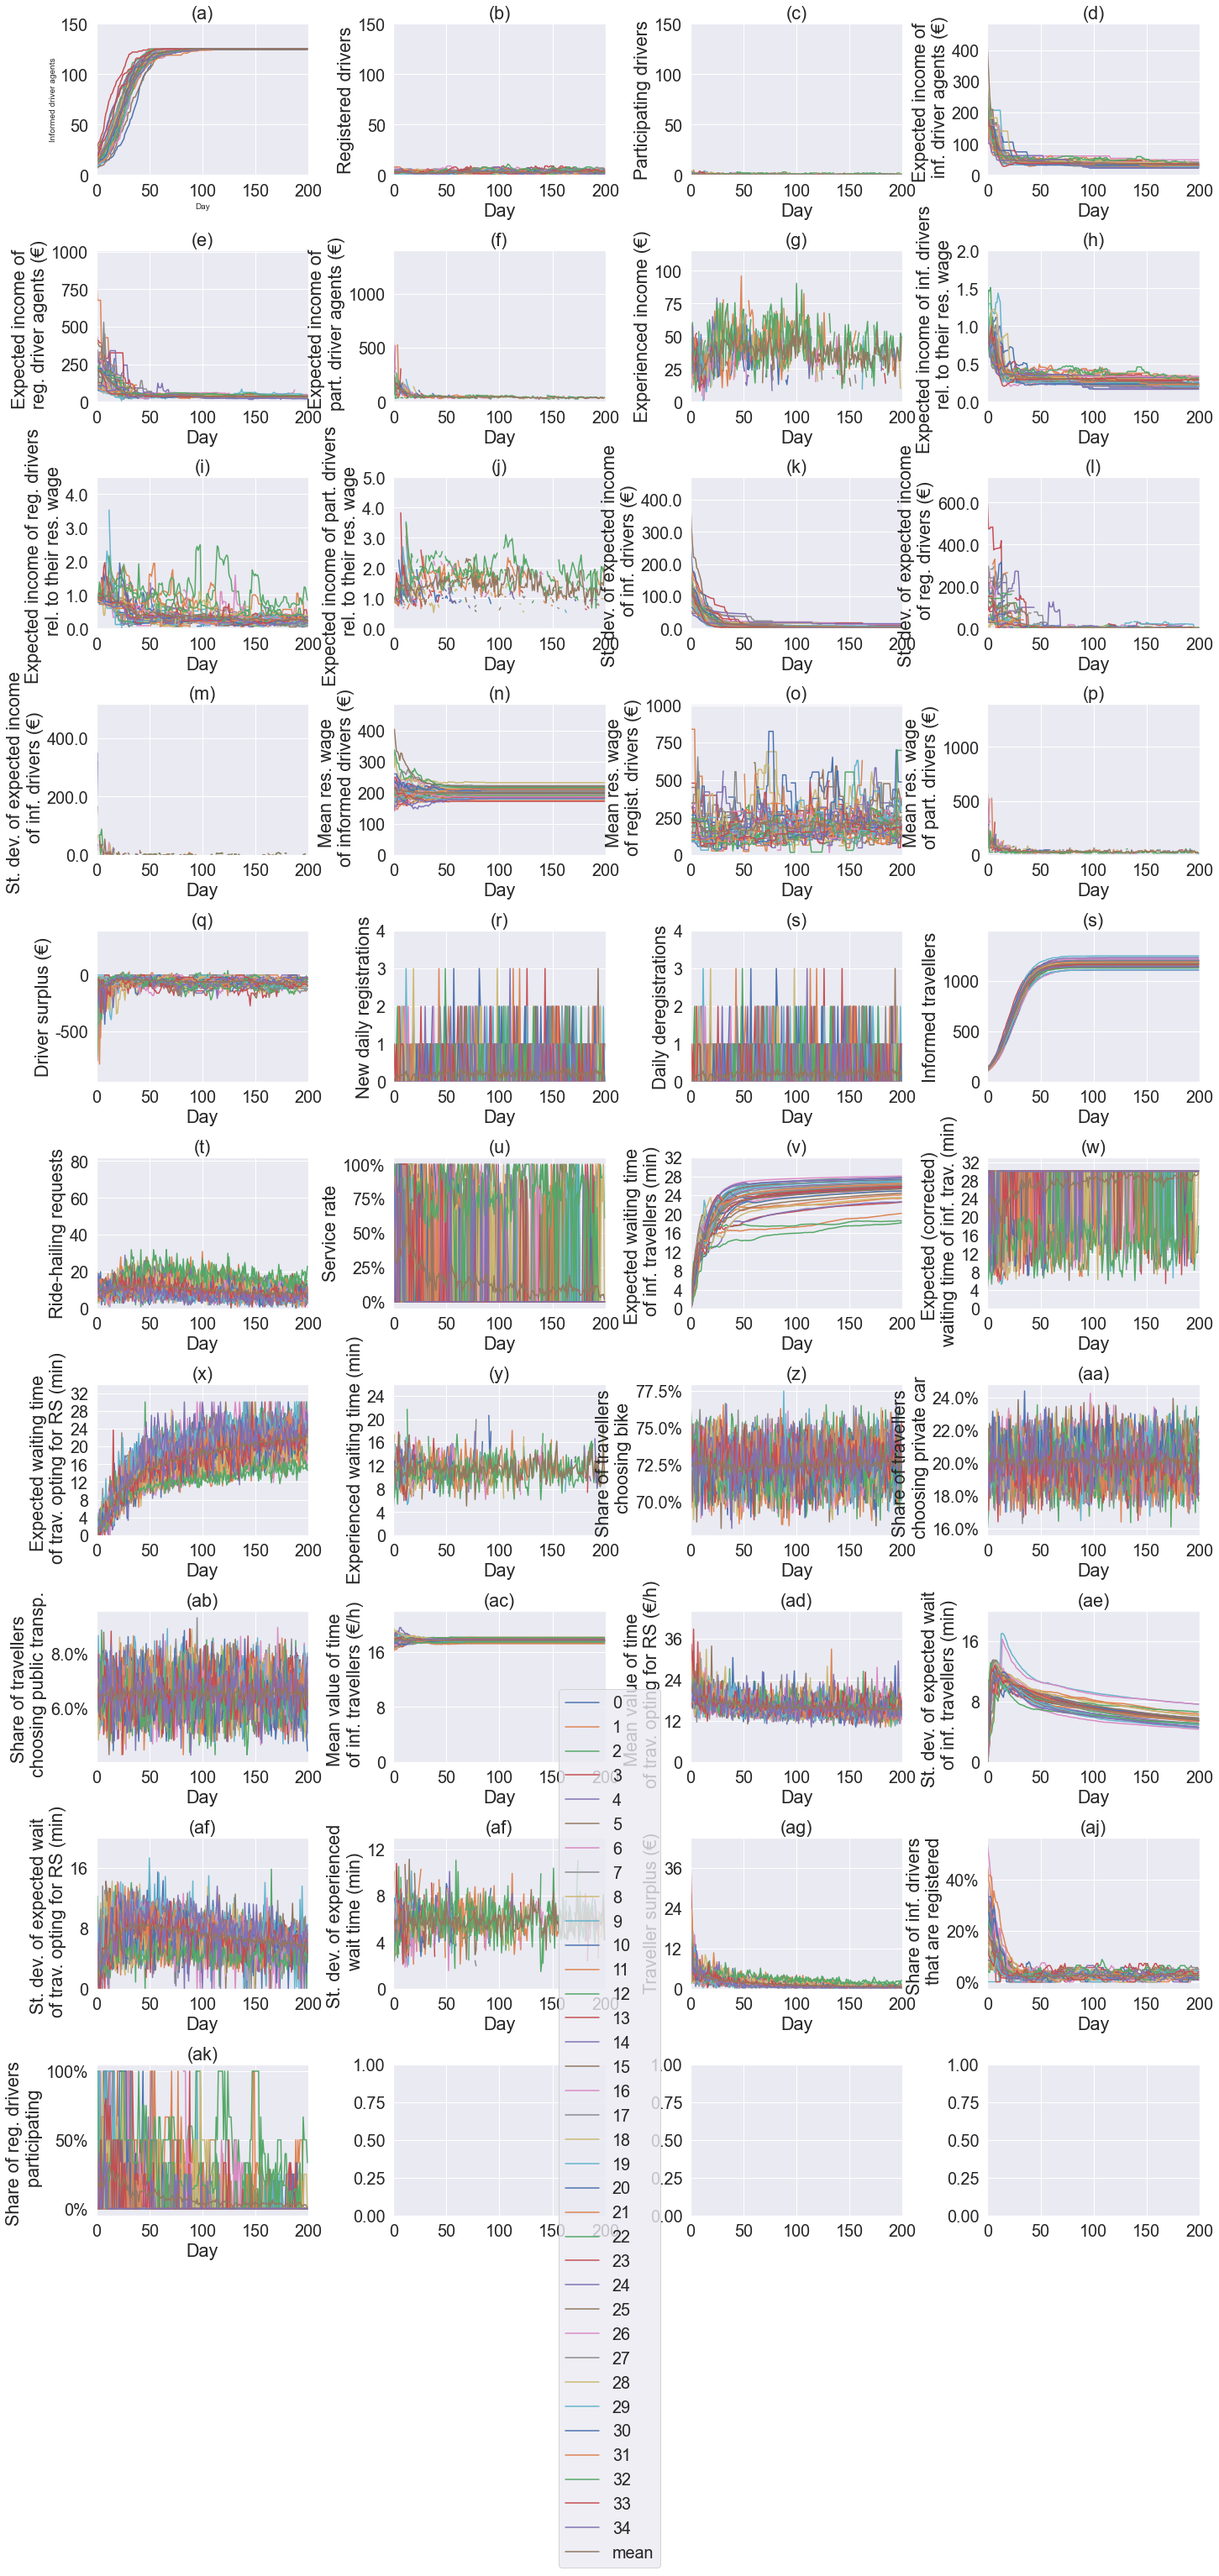

In [37]:
# Plot all runs within a single scenario - all indicators in one graph
scn_name = '3750_125'
fig = plot_multi_graph_runs(d2d.sup[scn_name], d2d.dem[scn_name])
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'run_dynamics_multi_fig.jpg'),dpi=300,bbox_inches='tight')

In [ ]:
# Plot all runs within a single scenario - all indicators in one graph
scn_name = '60000_125'
run_ids = d2d.sup[scn_name].inform.drop(['stdev','mean'],axis=1).columns.to_list()
# run_ids = [6,0]
fig, axes = plt.subplots(2, 3, figsize = [24,24])
 # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)
plt.setp(axes, xlim=[0,200])

axes[0, 0].plot(d2d.sup[scn_name].regist[run_ids])
axes[0, 0].set_ylabel('Registered driver agents', fontsize = 10)
axes[0, 0].set_xlabel('Day', fontsize = 10)
axes[0, 0].set_title('(a)')
axes[0, 0].set_ylim(bottom = 0, top = d2d.sup[scn_name].regist.max().max() + 25)
axes[0, 0].locator_params(axis='y', nbins=5)

axes[0, 1].plot(d2d.sup[scn_name].particip[run_ids])
axes[0, 1].set_ylabel('Participating driver agents', fontsize = 10)
axes[0, 1].set_xlabel('Day', fontsize = 10)
axes[0, 1].set_title('(b)')
axes[0, 1].set_ylim(bottom = 0, top = d2d.sup[scn_name].particip.max().max())
axes[0, 1].locator_params(axis='y', nbins=5)

axes[0, 2].plot(d2d.sup[scn_name].mean_perc_inc[run_ids])
axes[0, 2].set_ylabel('Expected income', fontsize = 10)
axes[0, 2].set_xlabel('Day', fontsize = 10)
axes[0, 2].set_title('(c)')
axes[0, 2].set_ylim(bottom = 0, top = d2d.sup[scn_name].mean_perc_inc.max().max())
axes[0, 2].locator_params(axis='y', nbins=5)

axes[1, 0].plot(d2d.dem[scn_name].perc_wait_req[run_ids])
axes[1, 0].set_ylabel('Expected wait time (s)', fontsize = 10)
axes[1, 0].set_xlabel('Day', fontsize = 10)
axes[1, 0].set_title('(c)')
axes[1, 0].set_ylim(bottom = 0, top = d2d.dem[scn_name].perc_wait_req.max().max())
axes[1, 0].locator_params(axis='y', nbins=5)

axes[1, 1].plot(d2d.dem[scn_name].requests[run_ids])
axes[1, 1].set_ylabel('Requests', fontsize = 10)
axes[1, 1].set_xlabel('Day', fontsize = 10)
axes[1, 1].set_title('(c)')
axes[1, 1].set_ylim(bottom = 0, top = d2d.dem[scn_name].requests.max().max())
axes[1, 1].locator_params(axis='y', nbins=5)

axes[1, 2].plot(d2d.dem[scn_name].gets_offer[run_ids])
axes[1, 2].set_ylabel('Service rate', fontsize = 10)
axes[1, 2].set_xlabel('Day', fontsize = 10)
axes[1, 2].set_title('(c)')
axes[1, 2].set_ylim(bottom = 0, top = d2d.dem[scn_name].gets_offer.max().max())
axes[1, 2].locator_params(axis='y', nbins=5)

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'run_dynamics_select.jpg'),dpi=300,bbox_inches='tight')

In [ ]:
# Plot an individual indicator
plot_inform = res_scn.sup.regist.plot()
plot_inform.set_ylabel("Volume of informed drivers")
plot_inform

In [ ]:
# kpi_eq.informed_drivers = round(kpi_eq.informed_drivers).astype(int)
# kpi_eq.regist_drivers = round(kpi_eq.regist_drivers).astype(int)
# kpi_eq.particip_drivers = round(kpi_eq.particip_drivers).astype(int)
# kpi_eq.requests = round(kpi_eq.requests).astype(int)
# kpi_eq.mean_perc_inc = round(kpi_eq.mean_perc_inc,2)
# kpi_eq.std_perc_inc = round(kpi_eq.std_perc_inc,2)
# kpi_eq.mean_exp_inc = round(kpi_eq.mean_exp_inc,2)
# kpi_eq.std_exp_inc = round(kpi_eq.std_exp_inc,2)
# kpi_eq.service_rate = round(kpi_eq.service_rate,1)
# kpi_eq.mean_wait_time = round(kpi_eq.mean_wait_time).astype(int)
# kpi_eq.exp_pure_wait = round(kpi_eq.exp_pure_wait).astype(int)
# kpi_eq.exp_wait_time = round(kpi_eq.exp_wait_time).astype(int)
# kpi_eq.std_perc_wait = round(kpi_eq.std_perc_wait).astype(int)
# kpi_eq.std_exp_wait = round(kpi_eq.std_exp_wait).astype(int)
# kpi_eq.std_corr_exp_wait = round(kpi_eq.std_corr_exp_wait).astype(int)
# kpi_eq.plf_profit = round(kpi_eq.plf_profit).astype(int)
# # kpi_eq = kpi_eq.drop(['perc_pax_reject'],axis=1)
# kpi_eq = kpi_eq[['informed_drivers','regist_drivers','particip_drivers', 'requests','mean_perc_inc','std_perc_inc','mean_exp_inc','std_exp_inc','service_rate','mean_wait_time','std_perc_wait','exp_pure_wait','std_exp_wait','exp_wait_time','std_corr_exp_wait','plf_profit']]

# Print equilibrium indicators as LateX table
# print(eql_scn.sup.astype('str').T.to_latex(index=True))
# print(eql_scn.dem.astype('str').T.to_latex(index=True))
# print(eql_scn.plf.astype('str').T.to_latex(index=True))

In [ ]:
# Plot indicators for single scenario (e.g. base scenario)
value = '75000_125' # specific scenario
fig = plot_single_scenario(res_scn, value)
fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

---

In [ ]:
pd.set_option('display.max_rows', 500)
micro.dem.corr_wait_time[45][['36','37']]

In [ ]:
res.dem[45].head(50)

In [ ]:
res.sup[38].head(50)

In [ ]:
# Investigating diagonal (for determination of representative sample size)
indices = [0.02,0.04,0.06,0.08,0.1,0.12,0.16,0.2,0.25]
labels = ['15000_500','30000_1000','45000_1500','60000_2000','75000_2500','90000_3000','120000_4000','150000_5000','187500_6250']

scal_sup = eql_scn.sup.loc(axis=0)[labels]
scal_sup.index = indices
scal_dem = eql_scn.dem.loc(axis=0)[labels]
scal_dem.index = indices
scal_plf = eql_scn.plf.loc(axis=0)[labels]
scal_plf.index = indices
# eql_scn.sup.loc['75000_2500'] / eql_scn.sup.loc['15000_500']
# eql_scn.dem.loc['75000_2500'] / eql_scn.dem.loc['15000_500']
# eql_scn.sup.loc['75000_2500'] / eql_scn.sup.loc['45000_1500']
# eql_scn.dem.loc['75000_2500'] / eql_scn.dem.loc['45000_1500']
# scal_sup.particip.plot()
# scal_sup.mean_perc_inc.plot()
# scal_dem.mean_wait.plot()

fig, axes = plt.subplots(2, 4, figsize = [24,10])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.2, wspace=0.3, left=.12, right=.88)

axes[0,0] = (scal_dem.perc_wait).plot(ax = axes[0,0], label='Expected')
axes[0,0] = (scal_dem.mean_wait).plot(ax = axes[0,0], label= 'Experienced')
axes[0,0].set_ylabel('Mean waiting time (s)')
axes[0,0].set_xlabel('Sample size')
axes[0, 0].set_ylim(bottom = 0) 
axes[0,0].legend()

axes[0,1] = (scal_dem.requests / scal_dem.inform).plot(ax = axes[0,1])
axes[0,1].set_ylabel('Share of travellers choosing RS')
axes[0,1].set_xlabel('Sample size')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 1].set_ylim(bottom = 0, top = 0.1)

axes[0,2] = (scal_sup.mean_perc_inc).plot(ax = axes[0,2], label = 'Expected')
axes[0,2] = (scal_sup.mean_exp_inc).plot(ax = axes[0,2], label = 'Experienced')
axes[0,2].set_ylabel('Mean perceived income (euro)')
axes[0,2].set_xlabel('Sample size')
# axes[0,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 2].set_ylim(bottom = 0, top = 100)
axes[0,2].legend()

axes[0,3] = (scal_sup.particip / scal_sup.inform).plot(ax = axes[0,3])
axes[0,3].set_ylabel('Share of driver agents participating')
axes[0,3].set_xlabel('Sample size')
axes[0,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 3].set_ylim(bottom = 0, top = 0.1) 

axes[1,0] = (scal_plf.plat_profit / scal_dem.inform).plot(ax = axes[1,0])
axes[1,0].set_ylabel('Platform profit per traveller in population (euro)')
axes[1,0].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 0].set_ylim(bottom = 0, top =0.2) 

axes[1,1] = (scal_dem.std_perc_wait).plot(ax = axes[1,1])
axes[1,1].set_ylabel('Standard dev. of expected waiting time (s)')
axes[1,1].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 1].set_ylim(bottom = 0) 

axes[1,2] = (scal_sup.std_perc_inc).plot(ax = axes[1,2])
axes[1,2].set_ylabel('St. dev. of perceived income (euro)')
axes[1,2].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 2].set_ylim(bottom = 0, top = 10) 

appr_runtime = pd.Series(index = indices, data = [5.25, 7.5, 15, 23, 28, 30, 44, 63.5, 85])
axes[1,3] = (appr_runtime).plot(ax = axes[1,3])
axes[1,3].set_ylabel('Approximate run time for 200 days for base scenario (h)')
axes[1,3].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 3].set_ylim(bottom = 0, top = 100) 

fig.savefig(os.path.join(os.getcwd(),"plots",'sample_effect.jpg'),dpi=300,bbox_inches='tight')

In [ ]:
kpis_dem

In [ ]:
# run_id = 0
# prefs = params[run_id]['evol']['travellers']['mode_pref']
# rs_ivt = requests[run_id].dist / params[run_id]['speeds']['ride']
# rs_fare = params[run_id]['platforms']['base_fare'] + params[run_id]['platforms']['fare'] * requests[run_id].dist / 1000
# rs_fare[rs_fare < params[run_id]['platforms']['min_fare']] = params[run_id]['platforms']['min_fare']
# beta_ivt = requests[run_id].VoT * prefs['beta_cost'] / 3600
# beta_wait = beta_ivt * prefs['wait_multip']
# U_rs = beta_ivt * rs_ivt + prefs['beta_cost'] * rs_fare + prefs['ASC_rs']
# U_wait = micro.dem.wait_time[run_id].mul(beta_wait, axis=0)
# U_wait_perc  = micro.dem.perc_wait[run_id].mul(beta_wait, axis=0)
# # U_rs = U_wait.add(U_rs, axis=0)
# U_rs = U_wait_perc.add(U_rs,axis=0)
# exp_U_rs = np.exp(U_rs)
# #         requests['U_rs'] = U_rs.copy()
# #         U_best_alt = requests[run_id][['U_pt','U_car','U_bike']].max(axis=1)
# exp_df = pd.DataFrame()
# exp_df['pt'] = np.exp(requests[run_id].U_pt)
# exp_df['car'] = np.exp(requests[run_id].U_car)
# exp_df['bike'] = np.exp(requests[run_id].U_bike)
# exp_sum_alt = exp_df.pt + exp_df.car + exp_df.bike

# exp_U_tot = exp_U_rs.add(exp_sum_alt, axis=0)
# exp_U_alts = exp_U_tot - exp_U_rs
# logsum_tot = np.log(exp_U_tot)
# logsum_alts = np.log(exp_U_alts)
# logsum_diff = logsum_tot - logsum_alts
# soc_welfare = (logsum_diff / -prefs['beta_cost']).sum(axis=0)

In [ ]:
eql_scn.soc.loc[eql_scn.soc.nP == 75000]

In [ ]:
# pd.set_option('display.max_columns', None)
# pd.set_option('display.expand_frame_repr', False)
# pd.set_option('max_colwidth', -1)
micro.dem.perc_wait[45]

In [ ]:
requests[45]

In [ ]:
eql_scn.sup.std_exp_inc / eql_scn.sup.mean_exp_inc

In [ ]:
params[0]

In [ ]:
eql_runs.sup['75000_125']

In [ ]:
eql_runs.dem['60000_250']

In [ ]:
var_val

In [ ]:
res.sup[0].mean_perc_inc_reg

In [ ]:
kokos = DotMap()
kokos['conv_factor'] = 0.01
kokos['conv_day'] = 5
perc_values = res.sup[0].mean_perc_inc_reg
df = pd.DataFrame()
df['t'] = perc_values
df['t-1'] = df.t.shift(1)
df = df.drop([0])
df['rdiff'] = (df['t'] - df['t-1']) / df['t-1']
df['stable'] = abs(df.rdiff) < kokos['conv_factor']
df['conv_cum'] = df.stable.cumsum()
df['conv_cum_early'] = df.conv_cum.shift(kokos['conv_day'])
df['conv'] = (df.conv_cum - df.conv_cum_early == kokos['conv_day'])
if df.conv.sum() == 0:
    t_conv = params['nD']-1
    perc_conv = perc_values[t_conv]
else:
    t_conv = df.index.get_loc(df.index[df.conv == True][0])
    perc_conv = df.iloc[t_conv].t
conv_res = [t_conv, perc_conv]

In [ ]:
micro.sup.exp_inc[295][~micro.sup.exp_inc[295]['1'].isna()]

In [ ]:
micro.sup.perc_inc[295][~micro.sup.perc_inc[295]['2'].isna()]

In [ ]:
micro.sup.ptcp[295][micro.sup.ptcp[295]['2']]

In [ ]:
d2d.sup['75000_125'].inform.head(40)

In [ ]:
a = 0
for i in range(0,len(res.sup)):
    one_ptcp = (res.sup[i].particip == 0)
    if one_ptcp.any():
        print('run_id {} has day with 0 participants - scenario {}'.format(i,scn.val[i]))
        a += 1
#     if res.sup[i][res.sup[i].particip == 1].shape[0] > 0:
#         print('run_id {} has one day with 1 participant'.format(i))

In [ ]:
len(res.sup)

In [ ]:
print(a)

In [ ]:
res.sup[0].mean_perc_inc.head(50)

In [ ]:
scn

In [ ]:
var_val

In [ ]:
res.sup[103].head(50)

In [ ]:
res.sup[14]

In [ ]:
eql_runs.sup['3750_2500']

In [ ]:
d2d.sup['3750_2500'].inform

In [ ]:
eql_stoch = pd.DataFrame(columns = ['ptcp', 'perc_inc', 'req', 'perc_wait'])
for item in vals:
    ind_1 = eql_runs.sup[item].particip.std() / eql_runs.sup[item].particip.mean() 
    ind_2 = eql_runs.sup[item].mean_perc_inc_reg.std() / eql_runs.sup[item].mean_perc_inc_reg.mean()
    ind_3 = eql_runs.dem[item].requests.std() / eql_runs.dem[item].requests.mean()
    ind_4 = eql_runs.dem[item].perc_wait_req.std() / eql_runs.dem[item].perc_wait_req.mean()
    series = pd.Series([ind_1,ind_2,ind_3,ind_4], index = eql_stoch.columns)
    eql_stoch = eql_stoch.append(series, ignore_index=True)
eql_stoch['scn'] = vals
eql_stoch.set_index('scn', inplace = True)
eql_stoch

In [ ]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 4, figsize = [24,6])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
# fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_stoch.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

res_proc['ptcp'] = eql_stoch.ptcp.copy()
axes[0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='ptcp'), ax = axes[0], cmap=cmap, vmin=0, vmax=0.4)
axes[0].set_title('Participation volume')
axes[0].invert_yaxis()

res_proc['perc_inc'] = eql_stoch.perc_inc.copy()
axes[1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='perc_inc'), ax = axes[1], cmap=cmap, vmin=0, vmax=0.4)
axes[1].set_title('Expected income')
axes[1].invert_yaxis()

res_proc['req'] = eql_stoch.req.copy()
axes[2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req'), ax = axes[2], cmap=cmap, vmin=0, vmax=0.4)
axes[2].set_title('Request volume')
axes[2].invert_yaxis()

res_proc['perc_wait'] = eql_stoch.perc_wait.copy()
axes[3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='perc_wait'), ax = axes[3], cmap=cmap, vmin=0, vmax=0.4)
axes[3].set_title('Expected waiting time')
axes[3].invert_yaxis()

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], '{}-{}_market-size-stochasticity.jpg'.format(variable_1["name"],variable_2["name"])),dpi=300,bbox_inches='tight')

In [ ]:
eql_scn.sup

In [ ]:
eql_runs.sup['15000_1000']

In [ ]:
eql_runs.dem['15000_1000']

In [ ]:
d2d.dem['3750_2500'].perc_wait.columns.tolist()

In [23]:
params[0]

{'NAME': 'default',
 'city': 'Amsterdam, Netherlands',
 'nP': 15000,
 'nV': 1000,
 'times': {'request': 15,
  'transaction': 20,
  'pickup': 30,
  'dropoff': 10,
  'patience': 600,
  'pickup_patience': 90},
 'speeds': {'walk': 1.2, 'ride': 10, 'bike': 4.0, 'pt': 5.0},
 't0': '2022-02-14 15:47:32',
 'paths': {'main': '/Users/rkucharski/Documents/GitHub/MaaSSim',
  'data': '/Users/rkucharski/Documents/GitHub/MaaSSim/data',
  'params': '/Users/rkucharski/Documents/GitHub/MaaSSim/data/configs',
  'G': 'data/graphs/Amsterdam.graphml',
  'skim': 'data/graphs/Amsterdam.csv',
  '_ipython_display_': {},
  '_repr_mimebundle_': {},
  '_repr_html_': {},
  '_repr_markdown_': {},
  '_repr_svg_': {},
  '_repr_png_': {},
  '_repr_pdf_': {},
  '_repr_jpeg_': {},
  '_repr_latex_': {},
  '_repr_json_': {},
  '_repr_javascript_': {},
  'albatross': 'data/albatross'},
 'dist_threshold': 100000,
 'big_time': 10,
 'sleep': False,
 'simTime': 8,
 'demand_structure': {'origins_dispertion': -0.0003,
  'destinat